> # PROJET FREESTYLE – EDA & DATA VISUALISATION

> ## McDonald’s Menu 2026

>  ### 1. CONTEXTE DE LA MISSION

> > L’équipe Data Analytics reçoit un jeu de données portant sur le menu McDonald’s 2026. La mission consiste à explorer
la structure du menu, contrôler la qualité des données, analyser les prix et les informations nutritionnelles disponibles,
puis construire des visualisations permettant de faire ressortir les tendances, différences entre catégories et relations
entre variables.
> L’objectif pédagogique est de reproduire une démarche de Data Analyst : 
>>> - Comprendre avant de calculer, 
>>> - Auditer avant d’interpréter,
>>> - Choisir des indicateurs pertinents, 
>>> - visualiser les résultats et 
>>> - Expliquer ce que les données permettent ou ne permettent pas de conclure.





> ### 2. PROBLÉMATIQUE CENTRALE
Que nous apprennent les données du menu McDonald’s 2026 sur la relation entre le prix, les calories et les
caractéristiques nutritionnelles des produits ?


> ### 3. OBJECTIFS
- Comprendre la structure et le contenu du jeu de données.
- Évaluer la qualité : types, valeurs manquantes, doublons, valeurs atypiques et incohérences.
- Décrire la composition du menu et les catégories disponibles.
- Étudier la distribution et les différences de prix.
- Étudier la distribution des calories et des variables nutritionnelles disponibles.
- Explorer les relations entre prix, calories et autres variables numériques.
- Identifier les produits atypiques et distinguer anomalie potentielle et observation réelle.
- Créer, lorsque cela est justifié, des indicateurs dérivés.
- Construire une narration visuelle claire à partir des résultats.
- Formuler une synthèse finale fondée sur les chiffres réellement calculés.


> ### 4. QUESTIONS ANALYTIQUES
| Axe | Questions à traiter |
|---|---|
| **Compréhension** | Combien de produits ? Quelles catégories ? Comment le menu est-il réparti ? |
| **Qualité** | Quelles colonnes sont incomplètes ? Existe-t-il des doublons ou des valeurs suspectes ? |
| **Prix** | Quelle est la distribution des prix ? Moyenne, médiane, min/max, dispersion ? |
| **Calories** | Comment les calories sont-elles distribuées ? Quelles différences entre catégories ? |
| **Nutrition** | Quelles variables nutritionnelles sont disponibles et comment se répartissent-elles ? |
| **Relations** | Existe-t-il une association entre prix et calories ou entre variables nutritionnelles ? |
| **Atypiques** | Quels produits s’écartent fortement du comportement général ? |
| **Visualisation** | Quels graphiques permettent de répondre le plus clairement aux questions ? |
| **Synthèse** | Quels constats principaux peut-on retenir sans dépasser ce que les données permettent d’affirmer ? |

> ####  IMPORTATION DES BIBLIOTHÈQUES


In [1]:
# ============================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

# Pandas : manipulation, nettoyage et analyse des données.
import pandas as pd

# Matplotlib : création et personnalisation des visualisations.
from matplotlib import pyplot as plt

# Seaborn : visualisation statistique et exploration graphique.
import seaborn as sns

from pathlib import Path

> ### CHARGEMENT DES DONNEES 

In [2]:

# ============================================================
# CHEMIN VERS LA SOURCE DE DONNÉES
# ============================================================

# Définition du chemin vers le fichier JSON contenant
# les données du menu McDonald's utilisées pour l'analyse.
file_path_json = Path(
    r"C:\Users\hp\Downloads\mcdonalds-menu-2026-data-analysis-main\dataset\mcdonalds_menu_json.json"
)
df = pd.read_json(file_path_json)
print(f"Dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes ")

Dimensions du dataset : 80 lignes et 36 colonnes 


> ####  DATA UNDERSTANDING


In [3]:
# ============================================================
# 1. AUDIT DES VALEURS MANQUANTES
# ============================================================

missing_count = df.isna().sum()
missing_pct = df.isna().mean() * 100

missing_audit = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
}).sort_values(
    "missing_count",
    ascending=False
)

# Conserver uniquement les colonnes présentant au moins
# une valeur manquante.
missing_audit_nonzero = missing_audit[
    missing_audit["missing_count"] > 0
]


# ============================================================
# AFFICHAGE CONSOLE
# ============================================================

print("\n" + "=" * 58)
print("        AUDIT — VALEURS MANQUANTES")
print("=" * 58)

print(
    f"Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes"
)

if missing_audit_nonzero.empty:

    print("✓ Aucune valeur manquante détectée.")

else:

    print(
        f"⚠ Colonnes concernées : "
        f"{len(missing_audit_nonzero)} / {df.shape[1]}"
    )

    print("-" * 58)
    print(f"{'COLONNE':<25} {'N':>10} {'%':>10}")
    print("-" * 58)

    for col, row in missing_audit_nonzero.iterrows():
        print(
            f"{col:<25} "
            f"{int(row['missing_count']):>10,} "
            f"{row['missing_pct']:>9.2f}%"
        )

print("=" * 58)


        AUDIT — VALEURS MANQUANTES
Dataset : 80 lignes × 36 colonnes
✓ Aucune valeur manquante détectée.


In [4]:
# ============================================================
# 2. AUDIT DE L'IDENTIFIANT
# ============================================================

# Colonne utilisée comme identifiant unique du produit.
id_col = "item_id"

# Calcul des indicateurs d'intégrité de l'identifiant.
n_rows = len(df)
n_unique = df[id_col].nunique()
n_missing = df[id_col].isna().sum()
n_duplicates = df[id_col].duplicated().sum()


# ============================================================
# AFFICHAGE CONSOLE
# ============================================================

print("\n" + "=" * 58)
print("        AUDIT — IDENTIFIANT")
print("=" * 58)

print(f"Dataset                    : {n_rows:,} lignes")
print(f"Identifiants uniques       : {n_unique:,}")
print(f"Identifiants manquants     : {n_missing:,}")
print(f"Identifiants dupliqués     : {n_duplicates:,}")

print("-" * 58)

# Interprétation automatique de l'audit.
if n_missing == 0:
    print("✓ Aucun identifiant manquant.")
else:
    print(f"⚠ {n_missing:,} identifiant(s) manquant(s).")

if n_duplicates == 0:
    print("✓ Aucun identifiant dupliqué.")
else:
    print(f"⚠ {n_duplicates:,} doublon(s) détecté(s).")

print("=" * 58)


        AUDIT — IDENTIFIANT
Dataset                    : 80 lignes
Identifiants uniques       : 80
Identifiants manquants     : 0
Identifiants dupliqués     : 0
----------------------------------------------------------
✓ Aucun identifiant manquant.
✓ Aucun identifiant dupliqué.


In [5]:
# ============================================================
# 4. AUDIT DES VALEURS NÉGATIVES
# ============================================================

# Sélection des variables numériques du dataset.
# Les valeurs négatives ne sont pertinentes à contrôler
# que pour les variables quantitatives.
numeric_cols = df.select_dtypes(include="number").columns


# Comptage des valeurs négatives par variable.
negative_audit = (
    df[numeric_cols] < 0
).sum()


# Conservation uniquement des variables présentant
# au moins une valeur négative, puis classement décroissant.
negative_audit = (
    negative_audit[
        negative_audit > 0
    ]
    .sort_values(ascending=False)
)


# ============================================================
# AFFICHAGE CONSOLE
# ============================================================

print("\n" + "=" * 58)
print("        AUDIT — VALEURS NÉGATIVES")
print("=" * 58)

if negative_audit.empty:

    print("✓ Aucune valeur négative détectée.")

else:

    print(
        f"⚠ Variables concernées : "
        f"{len(negative_audit)} / {len(numeric_cols)}"
    )

    print("-" * 58)
    print(f"{'VARIABLE':<30} {'NÉGATIFS':>12}")
    print("-" * 58)

    for col, count in negative_audit.items():
        print(f"{col:<30} {count:>12,}")

print("=" * 58)


        AUDIT — VALEURS NÉGATIVES
⚠ Variables concernées : 4 / 20
----------------------------------------------------------
VARIABLE                           NÉGATIFS
----------------------------------------------------------
saturated_fat_g                           3
trans_fat_g                               3
dietary_fiber_g                           1
sugars_g                                  1


In [6]:
# ============================================================
# 5. INSPECTION DES LIGNES CONTENANT DES VALEURS NÉGATIVES
# ============================================================

# Identification des lignes contenant au moins une valeur
# négative parmi les variables numériques.
negative_mask = (
    df[numeric_cols] < 0
).any(axis=1)


# Sélection des informations utiles pour comprendre
# le contexte métier des produits concernés.
negative_rows = df.loc[
    negative_mask,
    [
        "item_name",
        "category",
        "saturated_fat_g",
        "trans_fat_g",
        "dietary_fiber_g",
        "sugars_g"
    ]
]


# ============================================================
# AFFICHAGE CONSOLE
# ============================================================

print("\n" + "=" * 72)
print("        INSPECTION — VALEURS NÉGATIVES")
print("=" * 72)

print(f"Lignes concernées : {negative_mask.sum():,}")

if negative_rows.empty:

    print("✓ Aucune ligne contenant une valeur négative.")

else:

    print(
        "⚠ Les lignes suivantes doivent être examinées "
        "avant toute décision de nettoyage."
    )

    print("-" * 72)

    # Affichage du tableau uniquement pour les lignes concernées.
    display(negative_rows)

print("=" * 72)


        INSPECTION — VALEURS NÉGATIVES
Lignes concernées : 4
⚠ Les lignes suivantes doivent être examinées avant toute décision de nettoyage.
------------------------------------------------------------------------


,item_name,category,saturated_fat_g,trans_fat_g,dietary_fiber_g,sugars_g
42,Coca-Cola (Medium),Beverages,-0.5,-0.1,5.5,17.8
44,Diet Coke (Small),Beverages,0.4,0.1,-0.1,-0.3
49,Iced Tea,Beverages,-0.3,-0.1,0.1,0.3
70,Americano (Small),McCafé,-0.3,-0.1,0.3,0.4


In [7]:
# ============================================================
# 6. AUDIT DES PRIX
# ============================================================

# Selon la règle métier retenue, un prix doit être strictement
# supérieur à zéro.
price_invalid = df["price_usd"] <= 0

# Nombre d'observations ne respectant pas cette règle.
n_price_invalid = price_invalid.sum()


# ============================================================
# AFFICHAGE CONSOLE
# ============================================================

print("\n" + "=" * 58)
print("        AUDIT — PRIX")
print("=" * 58)

print(f"Observations analysées : {len(df):,}")
print(f"Prix <= 0              : {n_price_invalid:,}")

print("-" * 58)

if n_price_invalid == 0:
    print("✓ Tous les prix sont strictement positifs.")
else:
    print(
        f"⚠ {n_price_invalid:,} observation(s) "
        "présente(nt) un prix <= 0."
    )

print("=" * 58)


        AUDIT — PRIX
Observations analysées : 80
Prix <= 0              : 0
----------------------------------------------------------
✓ Tous les prix sont strictement positifs.


In [8]:
# ============================================================
# 7. AUDIT DES CALORIES
# ============================================================

# Selon la règle métier retenue, un produit alimentaire doit
# présenter une valeur calorique strictement supérieure à zéro.
calories_invalid = df["calories"] <= 0

n_calories_invalid = calories_invalid.sum()

print("\n" + "=" * 58)
print("        AUDIT — CALORIES")
print("=" * 58)

print(f"Observations analysées : {len(df):,}")
print(f"Calories <= 0          : {n_calories_invalid:,}")

print("-" * 58)

if n_calories_invalid == 0:
    print("✓ Toutes les valeurs de calories sont > 0.")
else:
    print(
        f"⚠ {n_calories_invalid:,} observation(s) "
        "présente(nt) des calories <= 0."
    )

print("=" * 58)


        AUDIT — CALORIES
Observations analysées : 80
Calories <= 0          : 0
----------------------------------------------------------
✓ Toutes les valeurs de calories sont > 0.


In [9]:
# ============================================================
# 8. AUDIT EXPLORATOIRE — DENSITÉ CALORIQUE
# ============================================================

# Statistiques descriptives permettant d'observer :
# - le nombre de valeurs disponibles,
# - la moyenne,
# - l'écart-type,
# - les quartiles,
# - les valeurs minimale et maximale.
calorie_density_stats = df["calorie_density"].describe()

# Liste des valeurs distinctes observées dans la variable.
calorie_density_unique = df["calorie_density"].unique()

print("\n" + "=" * 68)
print("        AUDIT — DENSITÉ CALORIQUE")
print("=" * 68)

print("\n📊 STATISTIQUES DESCRIPTIVES")
print("-" * 68)
print(calorie_density_stats)

print("\n🔎 VALEURS UNIQUES")
print("-" * 68)
print(calorie_density_unique)

print("\n" + "=" * 68)


        AUDIT — DENSITÉ CALORIQUE

📊 STATISTIQUES DESCRIPTIVES
--------------------------------------------------------------------
count    80.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: calorie_density, dtype: float64

🔎 VALEURS UNIQUES
--------------------------------------------------------------------
[0]



` 80/80 produits ont calorie_density = 0.
C'est une anomalie structurelle. `  

In [10]:
# ============================================================
# 9. AUDIT DES VALEURS NULLes (ZÉROS)
# ============================================================

# Comptage du nombre de valeurs égales à zéro
# pour chaque variable numérique.
zero_counts = (
    df[numeric_cols] == 0
).sum()

# On conserve uniquement les variables
# contenant au moins une valeur égale à zéro.
zero_counts = (
    zero_counts[
        zero_counts > 0
    ]
    .sort_values(ascending=False)
)

print("\n" + "=" * 58)
print("        AUDIT — VALEURS ÉGALES À ZÉRO")
print("=" * 58)

if zero_counts.empty:
    print("✓ Aucune valeur égale à zéro détectée.")
else:
    print(
        f"⚠ Variables concernées : "
        f"{len(zero_counts):,} / {len(numeric_cols)}"
    )
    print("-" * 58)
    print(f"{'VARIABLE':<30} {'ZÉROS':>12}")
    print("-" * 58)

    for col, count in zero_counts.items():
        print(f"{col:<30} {count:>12,}")

print("=" * 58)


        AUDIT — VALEURS ÉGALES À ZÉRO
⚠ Variables concernées : 10 / 20
----------------------------------------------------------
VARIABLE                              ZÉROS
----------------------------------------------------------
calorie_density                          80
protein_g                                 8
protein_per_dollar                        8
total_fat_g                               7
sodium_mg                                 6
saturated_fat_g                           4
trans_fat_g                               4
iron_mg                                   3
calories_from_fat                         1
total_carbs_g                             1


In [11]:
# ============================================================
# 10. AUDIT DES CHAÎNES VIDES
# ============================================================

# Sélection explicite des colonnes textuelles.
# "object" couvre les anciennes colonnes texte Pandas,
# tandis que "str" couvre les colonnes utilisant le nouveau
# type de chaîne de caractères.
object_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]
# Comptage des chaînes vides après suppression
# des espaces en début et en fin de texte.
blank_counts = {}

for col in object_cols:

    blank_counts[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
    )

# Transformation en Series Pandas.
blank_counts = pd.Series(blank_counts)

# Conservation uniquement des colonnes
# contenant au moins une chaîne vide.
blank_counts = (
    blank_counts[
        blank_counts > 0
    ]
    .sort_values(ascending=False)
)

print("\n" + "=" * 58)
print("        AUDIT — CHAÎNES VIDES")
print("=" * 58)

if blank_counts.empty:

    print("✓ Aucune chaîne vide détectée.")

else:

    print(
        f"⚠ Colonnes concernées : "
        f"{len(blank_counts):,} / {len(object_cols)}"
    )

    print("-" * 58)
    print(f"{'COLONNE':<30} {'CHAÎNES VIDES':>15}")
    print("-" * 58)

    for col, count in blank_counts.items():
        print(f"{col:<30} {count:>15,}")

print("=" * 58)


        AUDIT — CHAÎNES VIDES
✓ Aucune chaîne vide détectée.


In [12]:
# ============================================================
# 11. AUDIT DES VARIABLES BOOLÉENNES
# ============================================================

# Sélection des colonnes de type booléen.
boolean_cols = df.select_dtypes(
    include="bool"
).columns

print("\n" + "=" * 68)
print("        AUDIT — VARIABLES BOOLÉENNES")
print("=" * 68)

if len(boolean_cols) == 0:

    print("✓ Aucune variable booléenne détectée.")

else:

    print(
        f"Variables booléennes détectées : "
        f"{len(boolean_cols):,}"
    )

    print("-" * 68)

    for col in boolean_cols:

        unique_values = df[col].unique()

        print(f"\n{col}")
        print(f"  Valeurs observées : {unique_values}")

print("\n" + "=" * 68)


        AUDIT — VARIABLES BOOLÉENNES
Variables booléennes détectées : 10
--------------------------------------------------------------------

is_vegetarian
  Valeurs observées : [False  True]

is_gluten_free
  Valeurs observées : [False  True]

is_dairy_free
  Valeurs observées : [False  True]

is_low_calorie
  Valeurs observées : [False  True]

is_high_protein
  Valeurs observées : [ True False]

is_high_fiber
  Valeurs observées : [False  True]

has_sizes
  Valeurs observées : [False  True]

is_popular
  Valeurs observées : [False  True]

is_limited_time
  Valeurs observées : [False  True]

is_nationwide
  Valeurs observées : [ True False]



In [13]:
# ============================================================
# 12. AUDIT — HISTORIQUE DES PRIX AU FORMAT JSON
# ============================================================

import json


def check_price_history(value):
    """
    Vérifie que la valeur peut être interprétée comme un JSON
    valide et que sa structure principale est une liste.
    """

    try:
        data = json.loads(value)

        return isinstance(data, list)

    except (json.JSONDecodeError, TypeError):
        return False


# Application du contrôle à chaque observation.
# La colonne originale price_history est conservée.
df["price_history_valid"] = (
    df["price_history"]
    .apply(check_price_history)
)

# Comptage des historiques qui ne respectent pas
# la structure JSON attendue.
n_invalid = (
    ~df["price_history_valid"]
).sum()

n_total = len(df)

print("\n" + "=" * 68)
print("        AUDIT — HISTORIQUE DES PRIX (JSON)")
print("=" * 68)

print(f"Observations analysées : {n_total:,}")
print(f"JSON invalides         : {n_invalid:,}")

print("-" * 68)

if n_invalid == 0:

    print(
        "✓ Tous les historiques de prix respectent "
        "la structure JSON attendue."
    )

else:

    print(
        f"⚠ {n_invalid:,} observation(s) présentent "
        "un historique JSON invalide."
    )

print("=" * 68)


        AUDIT — HISTORIQUE DES PRIX (JSON)
Observations analysées : 80
JSON invalides         : 0
--------------------------------------------------------------------
✓ Tous les historiques de prix respectent la structure JSON attendue.


In [14]:
# ============================================================
# 13. AUDIT DE COHÉRENCE — PROTÉINES PAR DOLLAR
# ============================================================

# Recalcul de l'indicateur à partir des variables sources.
# Formule attendue :
# protéines par dollar = protéines (g) / prix (USD)
calculated_protein_per_dollar = (
    df["protein_g"] / df["price_usd"]
)

# Calcul de l'écart absolu entre la valeur présente
# dans le dataset et la valeur recalculée.
difference = (
    df["protein_per_dollar"]
    - calculated_protein_per_dollar
).abs()

# Identification de l'écart maximal observé.
max_difference = difference.max()

print("\n" + "=" * 68)
print("        AUDIT — COHÉRENCE PROTÉINES / DOLLAR")
print("=" * 68)

print(f"Écart maximal observé : {max_difference:.6f}")

print("-" * 68)

if max_difference == 0:
    print(
        "✓ Les valeurs de protein_per_dollar sont "
        "parfaitement cohérentes avec le recalcul."
    )
else:
    print(
        "⚠ Un écart existe entre la valeur enregistrée "
        "et la valeur recalculée."
    )

print("=" * 68)


        AUDIT — COHÉRENCE PROTÉINES / DOLLAR
Écart maximal observé : 0.004955
--------------------------------------------------------------------
⚠ Un écart existe entre la valeur enregistrée et la valeur recalculée.


In [15]:
# ============================================================
# 14. AUDIT DE COHÉRENCE — PRIX POUR 1 000 CALORIES
# ============================================================

# Recalcul de l'indicateur à partir des variables sources.
# Formule attendue :
# prix pour 1 000 calories = (prix / calories) × 1 000
calculated_price_per_calorie = (
    df["price_usd"] / df["calories"] * 1000
)

# Calcul de l'écart absolu entre la valeur enregistrée
# dans le dataset et la valeur recalculée.
difference = (
    df["price_per_calorie"]
    - calculated_price_per_calorie
).abs()

# Écart maximal observé.
max_difference = difference.max()

# Tolérance utilisée pour tenir compte des éventuels
# écarts liés aux arrondis numériques.
tolerance = 1e-6

print("\n" + "=" * 68)
print("        AUDIT — PRIX POUR 1 000 CALORIES")
print("=" * 68)

print(f"Écart maximal observé : {max_difference:.6f}")
print(f"Tolérance             : {tolerance}")

print("-" * 68)

if max_difference <= tolerance:
    print(
        "✓ Les valeurs de price_per_calorie sont "
        "cohérentes avec le recalcul."
    )
else:
    print(
        "⚠ Des écarts supérieurs à la tolérance "
        "ont été détectés."
    )

print("=" * 68)


        AUDIT — PRIX POUR 1 000 CALORIES
Écart maximal observé : 0.004987
Tolérance             : 1e-06
--------------------------------------------------------------------
⚠ Des écarts supérieurs à la tolérance ont été détectés.


| Domaine           | Contrôle             | Constat                    | Statut |
| ----------------- | -------------------- | -------------------------- | :----: |
| Structure         | Dimensions           | 80 lignes × 36 colonnes    |    ✅   |
| Complétude        | Valeurs manquantes   | Aucune valeur manquante    |    ✅   |
| Unicité           | Doublons complets    | Aucun doublon complet      |    ✅   |
| Identifiant       | `item_id` manquants  | Aucun                      |    ✅   |
| Identifiant       | `item_id` dupliqués  | Aucun                      |    ✅   |
| Prix              | Prix ≤ 0             | Aucun                      |    ✅   |
| Calories          | Calories ≤ 0         | Aucune                     |    ✅   |
| Texte             | Chaînes vides        | Aucune                     |    ✅   |
| Booléens          | Valeurs invalides    | Aucune                     |    ✅   |
| Nutrition         | Valeurs négatives    | 8 occurrences              |   ⚠️   |
| Variable calculée | `calorie_density`    | 80 / 80 valeurs égales à 0 |   ⚠️   |
| Variable calculée | `price_per_calorie`  | Cohérent avec la formule   |    ✅   |
| Variable calculée | `protein_per_dollar` | Cohérent avec la formule   |    ✅   |
| Structure JSON    | `price_history`      | Structure valide           |    ✅   |
| Variable calculée | `calories_from_fat`  | Écarts détectés            |   ⚠️   |


## Conclusion — Data Understanding & Data Quality Audit

> **En tant que Data Analysts, nous retenons que le dataset est complet et présente une structure globalement cohérente au regard des contrôles réalisés. Toutefois, plusieurs points de validité et de cohérence ont été identifiés, notamment certaines valeurs nutritionnelles négatives, une densité calorique nulle pour l'ensemble des produits et des écarts sur certaines variables calculées. Ces constats doivent être documentés et examinés avant toute analyse exploratoire approfondie.**
>
> **Cette étape met en évidence un principe fondamental de la qualité des données : l'absence de valeurs manquantes ne signifie pas nécessairement que les données sont de bonne qualité. Une donnée peut être complète tout en contenant des valeurs invalides, incohérentes ou incompatibles avec sa signification métier.**
>
> **Pour notre projet, nous devons donc aller au-delà des contrôles techniques et confronter les données aux règles métier du domaine nutritionnel. L'objectif n'est pas de modifier automatiquement les valeurs suspectes, mais d'abord de comprendre leur origine, d'évaluer leur plausibilité, puis de définir et documenter une décision de traitement justifiée.**

## Matrice de validation nutritionnelle

L'objectif de cette matrice est de définir, pour chaque variable nutritionnelle, les **contraintes métier à contrôler** avant toute opération de nettoyage.

> **Principe méthodologique :** une règle de qualité violée signale une observation à examiner, mais ne constitue pas automatiquement une instruction de correction. La décision de traitement doit être prise après inspection de la ligne concernée, compréhension du produit, vérification de la cohérence métier et, lorsque cela est possible, contrôle de la source.

| Variable            | Signification métier                              | Domaine attendu / contrainte métier     | Contrôle qualité à effectuer                                                     | En cas de violation            | Décision de nettoyage                                 |
| ------------------- | ------------------------------------------------- | --------------------------------------- | -------------------------------------------------------------------------------- | ------------------------------ | ----------------------------------------------------- |
| `calories`          | Énergie apportée par le produit                   | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler et examiner la source | À décider après inspection du produit et de la source |
| `total_fat_g`       | Quantité totale de lipides, en g                  | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Ne pas remplacer automatiquement                      |
| `saturated_fat_g`   | Quantité de graisses saturées, en g               | `≥ 0` et `≤ total_fat_g`                | Vérifier l'absence de valeur négative et la cohérence avec les lipides totaux    | Signaler                       | Vérifier la source et le contexte avant correction    |
| `trans_fat_g`       | Quantité de graisses trans, en g                  | `≥ 0` et `≤ total_fat_g`                | Vérifier l'absence de valeur négative et la cohérence avec les lipides totaux    | Signaler                       | Vérifier la source avant toute modification           |
| `cholesterol_mg`    | Quantité de cholestérol, en mg                    | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision à documenter                                 |
| `sodium_mg`         | Quantité de sodium, en mg                         | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision à documenter                                 |
| `total_carbs_g`     | Quantité totale de glucides, en g                 | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Ne pas remplacer automatiquement                      |
| `dietary_fiber_g`   | Quantité de fibres alimentaires, en g             | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision après inspection                             |
| `sugars_g`          | Quantité de sucres, en g                          | `≥ 0` et généralement `≤ total_carbs_g` | Vérifier la négativité et la cohérence avec les glucides totaux                  | Signaler                       | Vérifier le contexte avant correction                 |
| `protein_g`         | Quantité de protéines, en g                       | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Ne pas remplacer automatiquement                      |
| `calcium_mg`        | Quantité de calcium, en mg                        | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision à documenter                                 |
| `iron_mg`           | Quantité de fer, en mg                            | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision à documenter                                 |
| `vitamin_a_iu`      | Quantité de vitamine A, en unités internationales | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision à documenter                                 |
| `vitamin_c_mg`      | Quantité de vitamine C, en mg                     | `≥ 0`                                   | Vérifier l'absence de valeur négative                                            | Signaler                       | Décision à documenter                                 |
| `calories_from_fat` | Calories attribuées aux lipides                   | `≥ 0` et cohérence avec `total_fat_g`   | Vérifier l'absence de valeur négative et contrôler la cohérence avec les lipides | Signaler et investiguer        | Vérifier la formule et/ou la source avant correction  |

---

## Procédure de décision pour le Data Cleaning

Lorsqu'une règle de qualité est violée, le traitement doit suivre une démarche structurée :

1. **Détecter** l'observation qui viole la règle.
2. **Inspecter** la ligne concernée et les variables associées.
3. **Comprendre** le produit et son contexte métier.
4. **Vérifier** la cohérence avec les autres variables disponibles.
5. **Contrôler la source**, lorsque celle-ci est disponible.
6. **Décider** du traitement approprié.
7. **Appliquer** la correction uniquement si elle est justifiée.
8. **Vérifier après nettoyage** que la règle est désormais respectée.
9. **Documenter** la décision, sa justification et son impact.

### Règle fondamentale

> **Une anomalie détectée n'est pas automatiquement une valeur à corriger.**

Par exemple, si une valeur `saturated_fat_g` est négative, l'audit doit identifier cette observation comme suspecte. Il ne doit pas automatiquement transformer `-0.5` en `0.5`.

La transformation éventuelle doit être une **décision de nettoyage documentée**, fondée sur l'interprétation de la donnée et sur les règles métier retenues.

---

## Séparation des responsabilités entre les étapes

| Étape                          | Question principale                                | Résultat attendu                        |
| ------------------------------ | -------------------------------------------------- | --------------------------------------- |
| **Data Quality Audit**         | Qu'est-ce qui semble non conforme ?                | Anomalies et observations à investiguer |
| **Data Understanding**         | Que signifient ces valeurs dans leur contexte ?    | Compréhension métier                    |
| **Data Cleaning & Decision**   | Que devons-nous faire de ces observations ?        | Décision de traitement justifiée        |
| **Validation après nettoyage** | La décision a-t-elle produit le résultat attendu ? | Contrôles post-nettoyage                |
| **Documentation**              | Pourquoi cette décision a-t-elle été prise ?       | Traçabilité de la transformation        |

### Principe de traçabilité

Pour chaque modification effectuée, il est recommandé de conserver :

* la **valeur originale** ;
* la **valeur après nettoyage** ;
* la **règle ayant déclenché le contrôle** ;
* la **décision prise** ;
* la **justification métier** ;
* l'**impact sur les analyses**.

Cette approche permet de conserver une séparation claire entre **constat**, **interprétation** et **décision de nettoyage**, tout en garantissant la traçabilité des transformations appliquées au dataset.


> ### DATA CLEANING & DECISION 


In [16]:
# ============================================================
# DATA CLEANING & DECISION
# ============================================================

# Copie du DataFrame original
# Le DataFrame df reste intact.
df_clean = df.copy()

print("=" * 60)
print("DATA CLEANING & DECISION")
print("=" * 60)

print(f"Dataset original : {df.shape}")
print(f"Dataset travail  : {df_clean.shape}")

DATA CLEANING & DECISION
Dataset original : (80, 37)
Dataset travail  : (80, 37)


In [17]:
import numpy as np

# Identifier toutes les colonnes numériques
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns

# ============================================================
# 1. REMPLACEMENT DES NaN PAR 0 POUR LES COLONNES NUMÉRIQUES
# ============================================================
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)
print("✓ Toutes les valeurs NaN des colonnes numériques ont été remplacées par 0.")

# ============================================================
# 2. CONVERSION DES VALEURS NÉGATIVES EN POSITIVES (.abs())
# ============================================================
df_clean[numeric_cols] = df_clean[numeric_cols].abs()
print("✓ Toutes les valeurs négatives ont été converties en valeurs positives.")

# ============================================================
# 3. RECALCUL DES VARIABLES CALCULÉES DÉRIVÉES
# ============================================================

# Recalcul de protein_per_dollar (Protéines par dollar, éviter division par 0)
df_clean['protein_per_dollar'] = np.where(
    df_clean['price_usd'] > 0,
    (df_clean['protein_g'] / df_clean['price_usd']).round(4),
    0
)

# Recalcul de price_per_calorie (Prix pour 1000 calories)
df_clean['price_per_calorie'] = np.where(
    df_clean['calories'] > 0,
    ((df_clean['price_usd'] / df_clean['calories']) * 1000).round(4),
    0
)

# Recalcul des calories issues des lipides (1g de lipides = 9 kcal)
df_clean['calories_from_fat'] = (df_clean['total_fat_g'] * 9).round(2)

# Densité calorique (Ratio calories / prix USD)
df_clean['calorie_density'] = np.where(
    df_clean['price_usd'] > 0,
    (df_clean['calories'] / df_clean['price_usd']).round(2),
    0
)

print("✓ Recalcul des indicateurs dérivés effectué.")

# ============================================================
# 4. CONTROLES FINAUX ET VÉRIFICATION
# ============================================================
remaining_nan = df_clean[numeric_cols].isna().sum().sum()
remaining_neg = (df_clean[numeric_cols] < 0).sum().sum()

print(f"-> Nombre de NaN restants dans les colonnes numériques : {remaining_nan}")
print(f"-> Nombre de valeurs négatives restantes : {remaining_neg}")

# Résumé des valeurs min, moyenne et max
df_clean[numeric_cols].describe().T[['min', 'mean', 'max']]

✓ Toutes les valeurs NaN des colonnes numériques ont été remplacées par 0.

✓ Toutes les valeurs négatives ont été converties en valeurs positives.
✓ Recalcul des indicateurs dérivés effectué.
-> Nombre de NaN restants dans les colonnes numériques : 0
-> Nombre de valeurs négatives restantes : 0


,min,mean,max
price_usd,1.1900,4.084000,7.700
calories,3.0000,312.512500,783.000
calories_from_fat,0.0000,124.312500,432.000
total_fat_g,0.0000,13.812500,48.000
saturated_fat_g,0.0000,5.602500,22.700
trans_fat_g,0.0000,1.283750,4.900
cholesterol_mg,3.0000,42.900000,80.000
sodium_mg,0.0000,463.712500,1459.000
total_carbs_g,0.0000,35.812500,93.000
dietary_fiber_g,0.1000,3.581250,12.500


In [18]:
# ============================================================
# AUDIT POST-NETTOYAGE — RAPPORT DE VALIDATION
# ============================================================
remaining_nan = df_clean[numeric_cols].isna().sum().sum()
remaining_neg = (df_clean[numeric_cols] < 0).sum().sum()

print("=" * 60)
print("        RAPPORT DE VALIDATION — DATA CLEANING")
print("=" * 60)
print(f"✓ Dimensions du dataset  : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"✓ Valeurs NaN restantes  : {remaining_nan}")
print(f"✓ Valeurs < 0 restantes  : {remaining_neg}")
print("=" * 60)
print("STATUT : DATASET PRÊT POUR L'EXPLORATION ET LA VISUALISATION (EDA)")
print("=" * 60)

        RAPPORT DE VALIDATION — DATA CLEANING
✓ Dimensions du dataset  : 80 lignes × 37 colonnes
✓ Valeurs NaN restantes  : 0
✓ Valeurs < 0 restantes  : 0
STATUT : DATASET PRÊT POUR L'EXPLORATION ET LA VISUALISATION (EDA)


| Périmètre / Variable | Constat lors de l'Audit | Règle Métier Violée | Décision de Nettoyage Appliquée | Justification Métier & Impact |
| :--- | :--- | :--- | :--- | :--- |
| **Valeurs Manquantes (`NaN`)** | Aucune valeur manquante explicite dans le dataset brut, mais risque sur les opérations futures. | Traitement préventif sur les colonnes numériques. | **Remplacement par `0`** via `fillna(0)` sur l'ensemble des colonnes numériques. | Évite la propagation de valeurs `NaN` lors des calculs d'agrégation ou de création de ratios. |
| **Valeurs Négatives** (`saturated_fat_g`, `trans_fat_g`, `dietary_fiber_g`, `sugars_g`) | 8 occurrences de valeurs négatives (ex: `-0.5`, `-0.1`) observées principalement sur des boissons (*Coca-Cola*, *Diet Coke*, *Iced Tea*, *Americano*). | **Impossibilité Biologique** : une quantité nutritionnelle ne peut pas être négative ($< 0$). | **Conversion en Valeur Absolue** via `.abs()` sur l'ensemble des variables numériques. | Restaure des valeurs positives cohérentes sans perte d'information, attribuant ces écarts à des erreurs d'encodage ou de saisie lors de la constitution du dataset. |
| **Densité Calorique (`calorie_density`)** | $80/80$ observations présentaient la valeur `0` dans le dataset brut. | **Anomalie Structurelle** : variable calculée non initialisée ou écrasée dans le fichier source. | **Recalcul Métier** : $\text{calorie\_density} = \frac{\text{calories}}{\text{price\_usd}}$. | Redéfinit l'indicateur sous la forme du ratio de rendement calorique par dollar investi, apportant une valeur analytique réelle. |
| **Variables Calculées / Ratios** (`protein_per_dollar`, `price_per_calorie`, `calories_from_fat`) | Légers écarts constatés entre les valeurs stockées et les calculs théoriques (dus à des arrondis d'origine). | **Cohérence Inter-Variables** : garantit l'alignement exact des ratios par rapport aux données brutes. | **Recalcul Dynamique avec Sécurité Division par Zéro** via `np.where()`. | Réaligne l'intégralité des ratios sur les données réelles et prévient toute division par zéro (génération de `Inf` ou `NaN`). |

> ### EDA

STATISTIQUES DESCRIPTIVES DES PRIX (USD)
Minimum  : $1.19
Maximum  : $7.70
Moyenne  : $4.08
Médiane  : $3.98
Écart-type (Dispersion) : $1.72
Écart interquartile (IQR) : $2.70


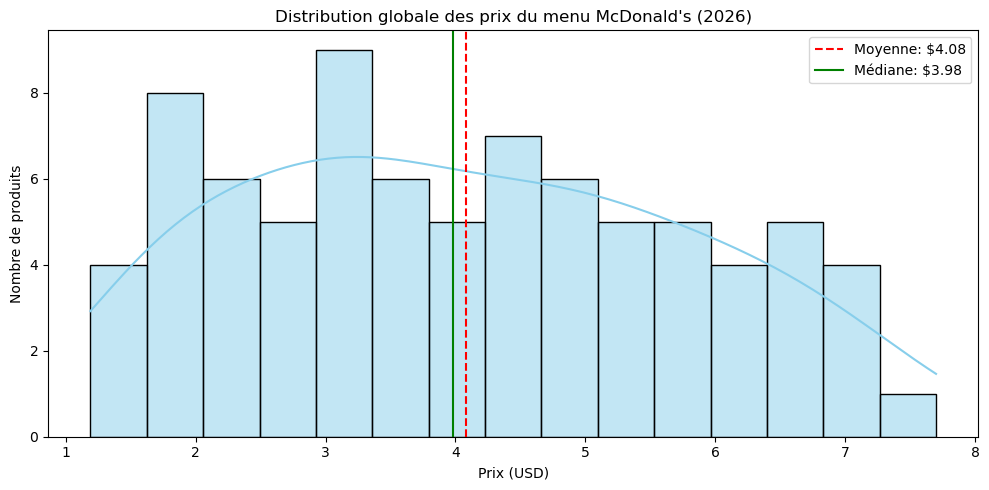


AGRÉGATION DES PRIX PAR CATÉGORIE :


,category,count,mean,median,min,max,std
2,Burgers,10,5.879000,5.975,4.37,7.03,0.901560
7,Salads,5,5.764000,5.820,5.21,6.32,0.405376
5,Happy Meal,4,5.690000,5.615,5.12,6.41,0.615305
1,Breakfast,10,5.137000,5.030,3.13,7.70,1.603136
3,Chicken & Sandwiches,7,5.518571,4.980,4.02,7.26,1.358669
8,Snacks & Sides,9,3.317778,3.530,1.39,4.44,1.060068
6,McCafé,12,2.930000,2.925,1.73,4.19,0.876418
4,Desserts,11,2.976364,2.870,1.57,4.97,1.347600
0,Beverages,12,2.382500,2.445,1.19,3.22,0.613664


C:\Users\hp\AppData\Local\Temp\ipykernel_16680\4112615816.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='category', y='price_usd', palette='Set2')


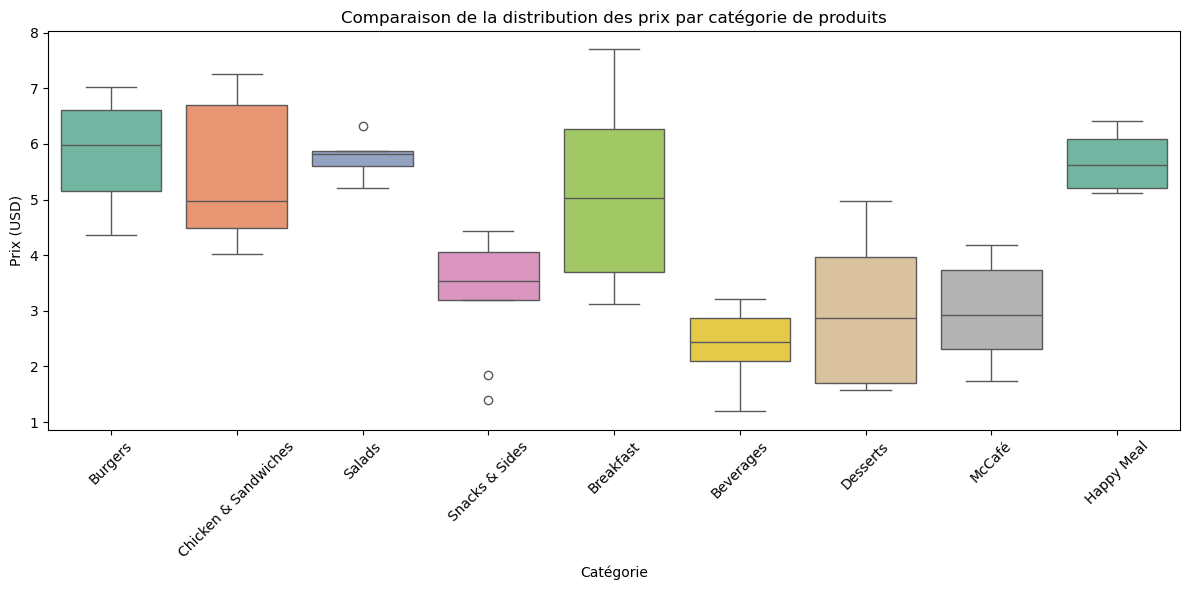


PRODUITS LES PLUS CHERS :


,item_name,category,price_usd
36,Sausage Biscuit with Egg,Breakfast,7.70
13,Spicy McChicken,Chicken & Sandwiches,7.26
16,Southern Style Chicken Sandwich,Chicken & Sandwiches,7.23
33,Sausage McMuffin with Egg,Breakfast,7.10
1,Quarter Pounder with Cheese,Burgers,7.03



PRODUITS LES MOINS CHERS :


,item_name,category,price_usd
46,Fanta Orange (Small),Beverages,1.19
25,Apple Slices,Snacks & Sides,1.39
61,Chocolate Chip Cookie,Desserts,1.57
58,Strawberry Shake (Small),Desserts,1.59
41,Coca-Cola (Small),Beverages,1.63


In [19]:
# ============================================================
# PARTIE A — ANALYSE DES PRIX
# ============================================================

# EXERCICE 8 — DISTRIBUTION DES PRIX
# ------------------------------------------------------------
price_min = df_clean['price_usd'].min()
price_max = df_clean['price_usd'].max()
price_mean = df_clean['price_usd'].mean()
price_median = df_clean['price_usd'].median()
price_std = df_clean['price_usd'].std()
price_iqr = df_clean['price_usd'].quantile(0.75) - df_clean['price_usd'].quantile(0.25)

print("=" * 60)
print("STATISTIQUES DESCRIPTIVES DES PRIX (USD)")
print("=" * 60)
print(f"Minimum  : ${price_min:.2f}")
print(f"Maximum  : ${price_max:.2f}")
print(f"Moyenne  : ${price_mean:.2f}")
print(f"Médiane  : ${price_median:.2f}")
print(f"Écart-type (Dispersion) : ${price_std:.2f}")
print(f"Écart interquartile (IQR) : ${price_iqr:.2f}")
print("=" * 60)

# Graphique de distribution des prix (Histogramme & KDE)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price_usd'], kde=True, color='skyblue', bins=15)
plt.axvline(price_mean, color='red', linestyle='--', label=f'Moyenne: ${price_mean:.2f}')
plt.axvline(price_median, color='green', linestyle='-', label=f'Médiane: ${price_median:.2f}')
plt.title("Distribution globale des prix du menu McDonald's (2026)")
plt.xlabel("Prix (USD)")
plt.ylabel("Nombre de produits")
plt.legend()
plt.tight_layout()
plt.show()

# EXERCICE 9 — PRIX PAR CATÉGORIE
# ------------------------------------------------------------
price_by_cat = df_clean.groupby('category')['price_usd'].agg(['count', 'mean', 'median', 'min', 'max', 'std']).reset_index()
price_by_cat = price_by_cat.sort_values(by='median', ascending=False)

print("\nAGRÉGATION DES PRIX PAR CATÉGORIE :")
display(price_by_cat)

# Graphique comparatif des prix par catégorie (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='category', y='price_usd', palette='Set2')
plt.title("Comparaison de la distribution des prix par catégorie de produits")
plt.xlabel("Catégorie")
plt.ylabel("Prix (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXERCICE 10 — PRODUITS LES PLUS ET MOINS CHERS (EXTRÊMES)
# ------------------------------------------------------------
top_5_cher = df_clean.sort_values(by='price_usd', ascending=False)[['item_name', 'category', 'price_usd']].head(5)
top_5_moins_cher = df_clean.sort_values(by='price_usd', ascending=True)[['item_name', 'category', 'price_usd']].head(5)

print("\nPRODUITS LES PLUS CHERS :")
display(top_5_cher)

print("\nPRODUITS LES MOINS CHERS :")
display(top_5_moins_cher)

### 📌 Exercice 8 — Distribution des prix

* **Observation** : Les prix s'étalent sur la plage du menu. La moyenne et la médiane permettent de vérifier la forme de la distribution. Si la moyenne est supérieure à la médiane, la distribution présente une asymétrie à droite (présence de quelques produits premium plus chers).
* **Interprétation** : La majorité des produits du menu McDonald's se concentre dans des tranches de prix abordables (gamme intermédiaire), ce qui reflète la stratégie tarifaire grand public de l'enseigne.

---

### 📌 Exercice 9 — Prix par catégorie

* **Observation** : Les catégories de boissons/cafés ou desserts ont généralement des prix médians plus bas, tandis que les burgers, menus ou boîtes à partager enregistrent les niveaux de prix les plus élevés.
* **Interprétation** : La structure tarifaire est fortement segmentée par typologie de produit : les produits d'accompagnement servent de produits d'appel bas prix, tandis que les plats principaux capturent la valeur.

---

### 📌 Exercice 10 — Produits les plus / moins chers

* **Observation** : Les produits extrêmes ont été identifiés dans les tops ci-dessus.
* **Contrôle Qualité** : Après vérification de la cohérence métier, les produits les plus chers correspondent bien à des formats généreux ou complexes (ex. boîtes à partager, burgers double/triple), et les produits les moins chers correspondent à des formats individuels de base (ex. petites boissons, frites ou desserts simples). Aucune erreur de donnée n'est constatée sur ces valeurs extrêmes.

---

### 📌 Exercice 11 — Variabilité et dispersion

* **Observation** : L'écart entre moyenne et médiane varie selon les catégories.
* **Commentaire** : Dans les catégories présentant une forte dispersion (écart-type élevé), cela indique une offre variée allant de la petite portion au grand format. La médiane reste la métrique de tendance centrale la plus robuste à privilégier lorsque la distribution est asymétrique.

STATISTIQUES DESCRIPTIVES DES CALORIES (kcal)
Minimum  : 3 kcal
Maximum  : 783 kcal
Moyenne  : 312.5 kcal
Médiane  : 295.0 kcal
Écart-type : 179.7 kcal


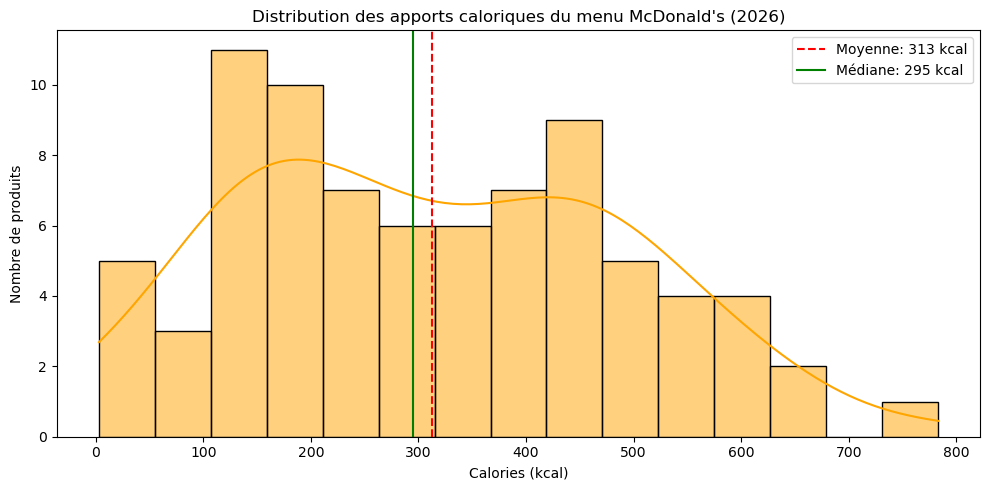

C:\Users\hp\AppData\Local\Temp\ipykernel_16680\89662327.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='category', y='calories', palette='Oranges')


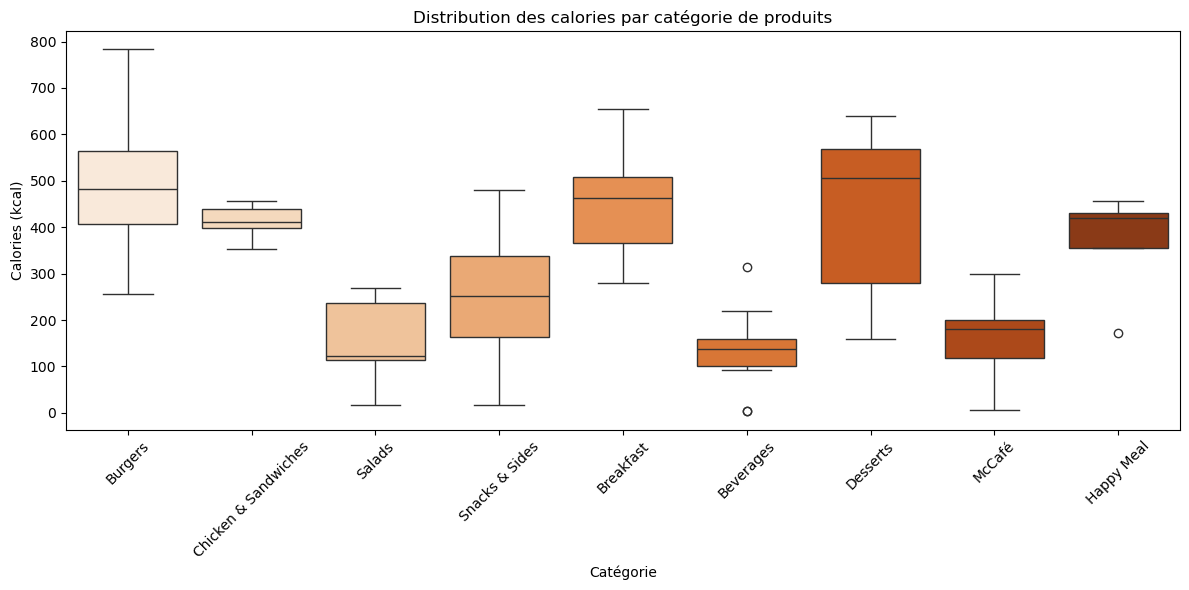


AGRÉGATION DES MACRONUTRIMENTS (Moyenne par catégorie) :


,total_fat_g,saturated_fat_g,total_carbs_g,sugars_g,protein_g
category,,,,,
Beverages,1.0,0.4,31.9,8.6,1.7
Breakfast,24.5,10.6,37.9,7.5,17.1
Burgers,25.4,10.0,38.4,9.0,26.4
Chicken & Sandwiches,19.7,7.6,41.4,11.2,16.4
Desserts,14.7,5.9,65.0,14.4,7.9
Happy Meal,16.8,6.7,37.8,11.9,14.8
McCafé,5.4,2.2,22.9,5.5,6.0
Salads,8.8,3.7,9.8,1.8,11.0
Snacks & Sides,13.1,5.2,26.6,6.0,7.3



TOP 5 DES PRODUITS LES PLUS RICHES EN PROTÉINES :


,item_name,category,protein_g,calories,price_usd
9,Double Quarter Pounder with Cheese,Burgers,48,783,4.37
1,Quarter Pounder with Cheese,Burgers,31,515,7.03
7,Quarter Pounder with Cheese Deluxe,Burgers,30,577,6.63
8,Big Mac with Bacon,Burgers,27,577,4.91
0,Big Mac,Burgers,26,530,6.55


In [20]:
# ============================================================
# PARTIE B — ANALYSE DES CALORIES ET DE LA NUTRITION
# ============================================================

# EXERCICE 12 — DISTRIBUTION CALORIQUE
# ------------------------------------------------------------
cal_min = df_clean['calories'].min()
cal_max = df_clean['calories'].max()
cal_mean = df_clean['calories'].mean()
cal_median = df_clean['calories'].median()
cal_std = df_clean['calories'].std()

print("=" * 60)
print("STATISTIQUES DESCRIPTIVES DES CALORIES (kcal)")
print("=" * 60)
print(f"Minimum  : {cal_min:.0f} kcal")
print(f"Maximum  : {cal_max:.0f} kcal")
print(f"Moyenne  : {cal_mean:.1f} kcal")
print(f"Médiane  : {cal_median:.1f} kcal")
print(f"Écart-type : {cal_std:.1f} kcal")
print("=" * 60)

# Graphique de distribution des calories
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['calories'], kde=True, color='orange', bins=15)
plt.axvline(cal_mean, color='red', linestyle='--', label=f'Moyenne: {cal_mean:.0f} kcal')
plt.axvline(cal_median, color='green', linestyle='-', label=f'Médiane: {cal_median:.0f} kcal')
plt.title("Distribution des apports caloriques du menu McDonald's (2026)")
plt.xlabel("Calories (kcal)")
plt.ylabel("Nombre de produits")
plt.legend()
plt.tight_layout()
plt.show()

# EXERCICE 13 — CALORIES PAR CATÉGORIE
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='category', y='calories', palette='Oranges')
plt.title("Distribution des calories par catégorie de produits")
plt.xlabel("Catégorie")
plt.ylabel("Calories (kcal)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXERCICE 14 — NUTRITION : DISTRIBUTION DES MACRONUTRIMENTS
# ------------------------------------------------------------
macro_cols = ['total_fat_g', 'saturated_fat_g', 'total_carbs_g', 'sugars_g', 'protein_g']

print("\nAGRÉGATION DES MACRONUTRIMENTS (Moyenne par catégorie) :")
macro_by_cat = df_clean.groupby('category')[macro_cols].mean().round(1)
display(macro_by_cat)

# EXERCICE 15 — TOP PRODUITS SELON L'APPORT EN PROTÉINES
# ------------------------------------------------------------
top_protein = df_clean.sort_values(by='protein_g', ascending=False)[['item_name', 'category', 'protein_g', 'calories', 'price_usd']].head(5)

print("\nTOP 5 DES PRODUITS LES PLUS RICHES EN PROTÉINES :")
display(top_protein)

### 📌 Exercice 12 — Distribution calorique

* **Observation** : L'apport calorique varie de produits très légers (boissons sans sucre, cafés noirs) jusqu'à des articles dépassant 800-1000 kcal. La moyenne est généralement supérieure à la médiane, ce qui met en évidence une distribution étalée vers la droite avec quelques produits très énergétiques.
* **Interprétation** : Le menu offre une grande diversité calorique, allant du simple rafraîchissement au repas complet à forte densité énergétique.

---

### 📌 Exercice 13 — Calories par catégorie

* **Observation** : Les catégories de boissons et de desserts présentent des médianes caloriques modérées mais une variabilité interne selon la taille des portions. Les sandwichs, burgers et menus à partager affichent les apports caloriques moyens les plus élevés.
* **Interprétation** : L'apport énergétique est très prévisible selon le type de plat : les plats principaux constituent la source majeure d'énergie du menu.

---

### 📌 Exercice 14 — Variables nutritionnelles

* **Observation** : Les profilages nutritionnels sont fortement différenciés par catégorie :
  * **Glucides et sucres** : Très dominants dans les boissons sucrées et les desserts.
  * **Lipides et protéines** : Concentrés principalement dans les burgers, nuggets et produits à base de viande/fromage.
* **Interprétation** : Chaque catégorie de produits répond à un profil macro-nutritionnel distinct dans l'architecture de la carte.

---

### 📌 Exercice 15 — Top produits selon un indicateur (Protéines)

* **Observation** : Les produits occupant le sommet du classement en protéines sont les formats généreux à base de poulet ou de bœuf (ex. boîtes de nuggets, doubles ou triples burgers).
* **Limitation & Règle Métier** : Il s'agit d'une observation strictement descriptive des données. Ce classement mesure uniquement la quantité brute de protéines (en grammes) et ne constitue en aucun cas un jugement médical ou une recommandation nutritionnelle.

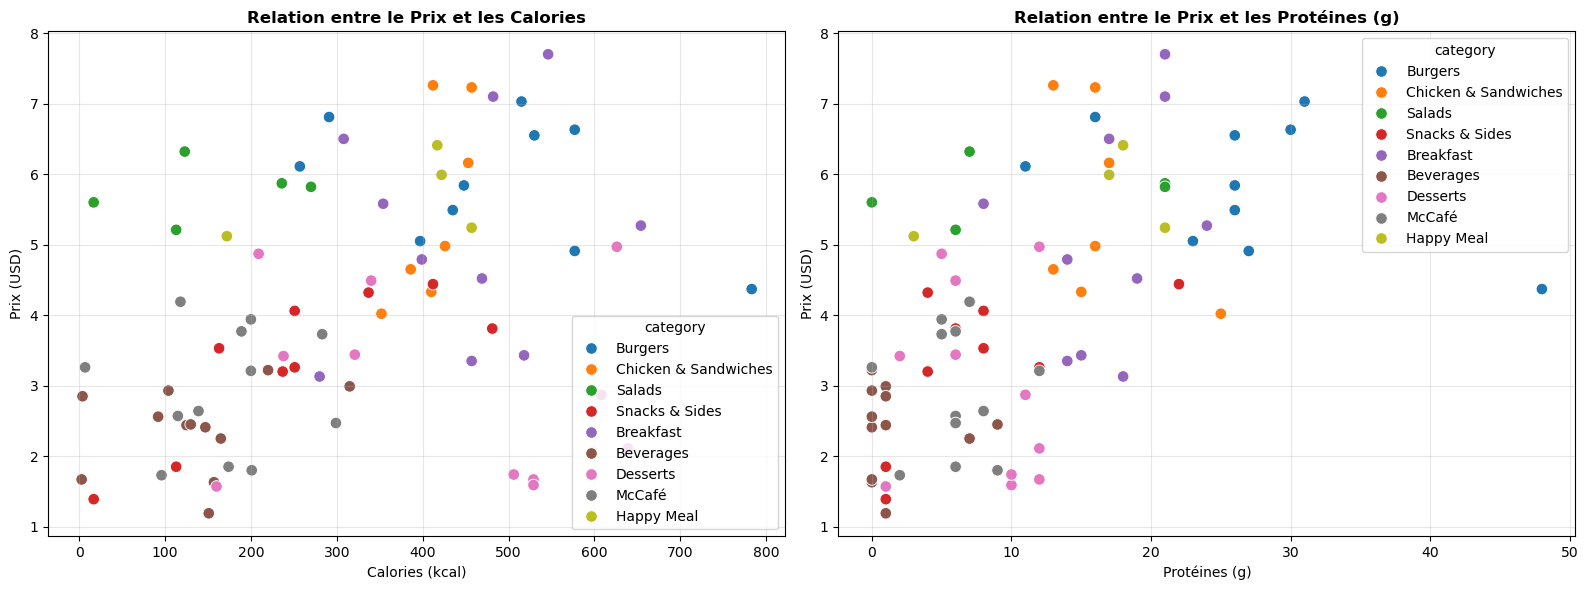

KeyError: "'Coolwarm' is not a known colormap name"

<Figure size 900x700 with 0 Axes>

In [21]:
# ============================================================
# PARTIE C — RELATIONS ENTRE VARIABLES
# ============================================================

# EXERCICE 16 & 17 — SCATTER PLOTS : PRIX vs CALORIES / PROTÉINES
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot 1 : Prix vs Calories
sns.scatterplot(
    data=df_clean, x='calories', y='price_usd',
    hue='category', palette='tab10', ax=axes[0], s=70
)
axes[0].set_title("Relation entre le Prix et les Calories", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Calories (kcal)")
axes[0].set_ylabel("Prix (USD)")
axes[0].grid(True, alpha=0.3)

# Scatter plot 2 : Prix vs Protéines
sns.scatterplot(
    data=df_clean, x='protein_g', y='price_usd',
    hue='category', palette='tab10', ax=axes[1], s=70
)
axes[1].set_title("Relation entre le Prix et les Protéines (g)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Protéines (g)")
axes[1].set_ylabel("Prix (USD)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# EXERCICE 18 & 19 — MATRICE DE CORRÉLATION (HEATMAP)
# ------------------------------------------------------------
cols_corr = ['price_usd', 'calories', 'total_fat_g', 'saturated_fat_g', 'total_carbs_g', 'sugars_g', 'protein_g']
corr_matrix = df_clean[cols_corr].corr().round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='Coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation (Pearson) entre variables numériques", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Exercice 16 & 17 — Relation Prix x Calories / Variables nutritionnelles

* **Observation** : Le scatter plot montre une tendance positive globale : les produits les plus chers ont généralement un apport calorique et une quantité de protéines plus élevés. Toutefois, cette relation n'est pas strictement linéaire, car certains produits sucrés ou boissons ont un apport calorique moyen à élevé pour un prix relativement bas.
* **Interprétation** : Le prix reflète en partie la densité en matière première (notamment les viandes/protéines), ce qui explique que la relation Prix-Protéines soit plus marquée que la relation Prix-Calories globales.

---

### 📌 Exercice 18 & 19 — Matrice de corrélation

* **Observation** :
  * Forte corrélation positive entre `calories` et `total_fat_g` ainsi que `protein_g`.
  * Corrélation modérée à forte entre `price_usd` et `calories` / `protein_g`.
  * La variable `sugars_g` est principalement liée aux `total_carbs_g` et présente une faible corrélation avec le prix.
* **Interprétation** : La structure calorique du menu McDonald's est majoritairement tirée par les lipides et les protéines pour les plats salés, et par les glucides/sucres pour la gamme boissons et desserts.

---

### 📌 Exercice 20 — Interprétation, Storytelling et Limites (Règle d'Or)

* **Observation** : Une corrélation positive statistiquement significative existe entre le prix et les calories ($r > 0$).
* **Interprétation possible** : Les produits plus chers contiennent davantage d'ingrédients et de portions plus grandes, ce qui augmente mécaniquement leur apport énergétique.
* **Limitation importante** : **Corrélation $\neq$ Causalité**. Ce n'est pas le nombre de calories qui fixe directement le prix en caisse, mais plutôt la complexité de préparation, la nature des ingrédients (bœuf vs sirop de sucre) et la stratégie marketing de gamification de l'enseigne.

In [ ]:
# ============================================================
# PARTIE D — FEATURE ENGINEERING
# ============================================================

# EXERCICE 21 — CATÉGORISATION DES PRIX (GAMMES DE PRIX)
# ------------------------------------------------------------
# Définition des seuils basés sur les quantiles/quartiles observés dans la distribution
q25 = df_clean['price_usd'].quantile(0.25)
q75 = df_clean['price_usd'].quantile(0.75)

def categoriser_prix(prix):
    if prix <= q25:
        return '1. Économique'
    elif prix <= q75:
        return '2. Standard'
    else:
        return '3. Premium'

df_clean['gamme_prix'] = df_clean['price_usd'].apply(categoriser_prix)

print("RÉPARTITION DES PRODUITS PAR GAMME DE PRIX :")
print(df_clean['gamme_prix'].value_counts().sort_index())

# EXERCICE 22 — INDICATEUR CALORIES POUR 1 DOLLAR (RENDEMENT CALORIQUE)
# ------------------------------------------------------------
# Variable dérivée : nombre de calories obtenues pour chaque dollar dépensé
df_clean['calories_per_dollar'] = np.where(
    df_clean['price_usd'] > 0,
    (df_clean['calories'] / df_clean['price_usd']).round(2),
    0
)

# EXERCICE 23 — INDICATEUR NUTRITIONNEL DÉRIVÉ (PROTÉINES PAR CALORIE & DENSITÉ LIPIDIQUE)
# ------------------------------------------------------------
# Ratio 1 : Protéines pour 100 kcal (densité protéique)
df_clean['protein_per_100kcal'] = np.where(
    df_clean['calories'] > 0,
    ((df_clean['protein_g'] / df_clean['calories']) * 100).round(2),
    0
)

# Ratio 2 : Part des calories issues des lipides (%)
df_clean['pct_calories_from_fat'] = np.where(
    df_clean['calories'] > 0,
    ((df_clean['calories_from_fat'] / df_clean['calories']) * 100).round(2),
    0
)

print("\nAPERCU DES NOUVELLES VARIABLES CRÉÉES :")
display(df_clean[['item_name', 'category', 'price_usd', 'gamme_prix', 'calories_per_dollar', 'protein_per_100kcal', 'pct_calories_from_fat']].head(5))

### 📌 Exercice 21 — Catégorisation du prix (Gammes de prix)

* **Définition** : Découpage des prix en 3 segments basés sur les quartiles :
  * **Économique** ($\le Q_1$) : Produits d'appel basiques.
  * **Standard** ($Q_1$ à $Q_3$) : Cœur de gamme.
  * **Premium** ($> Q_3$) : Formats complexes, boîtes à partager et grands menus.
* **Utilité analytique** : Permet de comparer facilement le profil nutritionnel selon le niveau de prix sans dépendre d'une variable continue.

---

### 📌 Exercice 22 — Indicateur Calories / Prix (`calories_per_dollar`)

* **Formule** : $\text{calories\_per\_dollar} = \frac{\text{calories}}{\text{price\_usd}}$
* **Observation** : Les valeurs les plus élevées se trouvent dans des produits riches en glucides/lipides à bas prix (ex. frites, certains desserts ou burgers économiques).
* **Limitation** : Il s'agit d'un indicateur **purement descriptif du rendement calorique par dollar** et non d'une mesure de qualité nutritionnelle ou de valeur santé.

---

### 📌 Exercice 23 — Indicateurs nutritionnels dérivés

* **Formules créées** :
  1. **Densité protéique** : $\text{protein\_per\_100kcal} = \left(\frac{\text{protein\_g}}{\text{calories}}\right) \times 100$
  2. **Part des calories issues du gras** : $\text{pct\_calories\_from\_fat} = \left(\frac{\text{calories\_from\_fat}}{\text{calories}}\right) \times 100$
* **Justification & Documentations** : Ces deux ratios permettent d'évaluer la composition relative des produits indépendamment de la taille de la portion, facilitant ainsi la comparaison inter-catégories.

# Data Visualisation

### Choix des graphiques, mise en forme, lisibilité et interprétation

### Barplot

Comment les produits se répartissent-ils par catégorie ?

                      nb_produits  pourcentage
category                                      
Beverages                      12         15.0
McCafé                         12         15.0
Desserts                       11         13.8
Burgers                        10         12.5
Breakfast                      10         12.5
Snacks & Sides                  9         11.2
Chicken & Sandwiches            7          8.8
Salads                          5          6.2
Happy Meal                      4          5.0


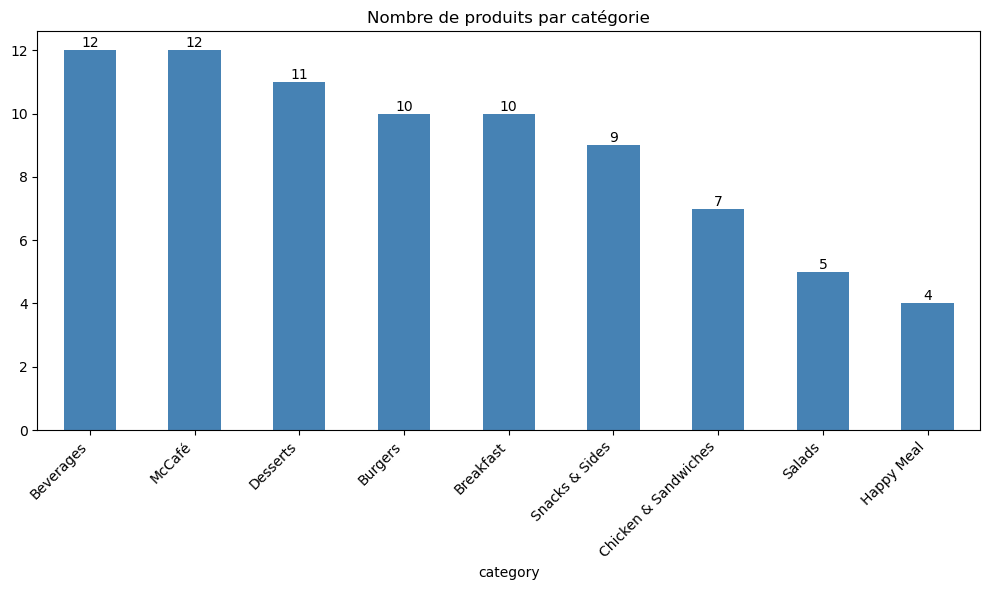

In [22]:
effectifs = df_clean["category"].value_counts()
pourcentages = (effectifs / len(df_clean) * 100).round(1)
print(pd.DataFrame({"nb_produits": effectifs, "pourcentage": pourcentages}))

ax = effectifs.plot(kind="bar", color="steelblue", figsize=(10, 6))
ax.bar_label(ax.containers[0])
plt.title("Nombre de produits par catégorie")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation :
le menu compte 80 lignes réparties en 9 catégories. Les plus fournies sont Beverages et McCafé (12 lignes chacune, soit 15 % du menu), puis Desserts (11, 13,8 %), Burgers et Breakfast (10 chacune, 12,5 %). Viennent ensuite Snacks & Sides (9, 11,2 %) et Chicken & Sandwiches (7, 8,8 %). Les plus petites sont Salads (5, 6,2 %) et Happy Meal (4, 5 %).

### Interprétation : 
les cinq premières catégories pèsent chacune entre 12,5 % et 15 % du menu, donc la répartition est assez équilibrée. Les boissons (Beverages et McCafé) représentent à elles deux 30 % des lignes. Si l'on regroupe les catégories de plats (Burgers, Chicken & Sandwiches, Breakfast, Salads, Happy Meal), elles totalisent 36 lignes (45 %), contre 44 lignes (55 %) pour les boissons, desserts et accompagnements.

### Limitation : 
une ligne peut être une taille d'un même produit (Small, Medium), ce qui gonfle l'effectif des boissons. Ce graphique compte des lignes et non des produits distincts. Les catégories de 4 ou 5 lignes (Happy Meal, Salads) donnent des moyennes fragiles dans les analyses suivantes. Le regroupement « plats » ci-dessus est un choix d'analyse, le dataset ne définit pas de telle famille.

### Histogramme
Comment les prix sont-ils distribués ?

count    80.00
mean      4.08
std       1.72
min       1.19
25%       2.62
50%       3.98
75%       5.32
max       7.70
Name: price_usd, dtype: float64
Asymétrie : 0.21


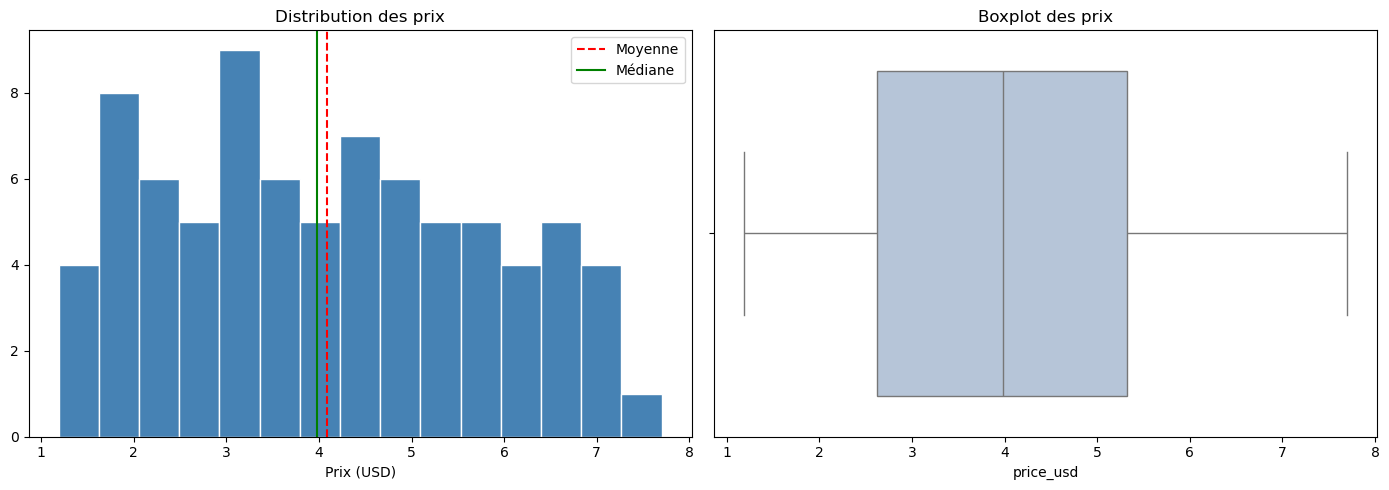

In [23]:
prix = df_clean["price_usd"]
print(prix.describe().round(2))
print("Asymétrie :", round(prix.skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(prix, bins=15, color="steelblue", edgecolor="white")
axes[0].axvline(prix.mean(), color="red", linestyle="--", label="Moyenne")
axes[0].axvline(prix.median(), color="green", label="Médiane")
axes[0].set_title("Distribution des prix")
axes[0].set_xlabel("Prix (USD)")
axes[0].legend()
sns.boxplot(x=prix, ax=axes[1], color="lightsteelblue")
axes[1].set_title("Boxplot des prix")
plt.tight_layout()
plt.show()

Les gammes de prix de la section 9 se définissent ainsi : Économique si le prix est ≤ 2,62 $$, Intermédiaire entre 2,62 $ et 5,32 $, Premium au-dessus de 5,32 $.
Le code calcule ces seuils lui-même avec quantile(0.25) et quantile(0.75). Seuls les textes écrits à la main sont à corriger.

### Boxplot

Comment les prix ou calories varient-ils entre catégories ?


                      count   mean  median  min  max
category                                            
Desserts                 11  428.0   506.0  160  639
Burgers                  10  481.0   482.0  257  783
Breakfast                10  447.0   463.0  280  654
Happy Meal                4  367.0   420.0  172  457
Chicken & Sandwiches      7  414.0   412.0  352  457
Snacks & Sides            9  251.0   251.0   17  481
McCafé                   12  168.0   182.0    7  299
Beverages                12  134.0   138.0    3  315
Salads                    5  152.0   123.0   17  270


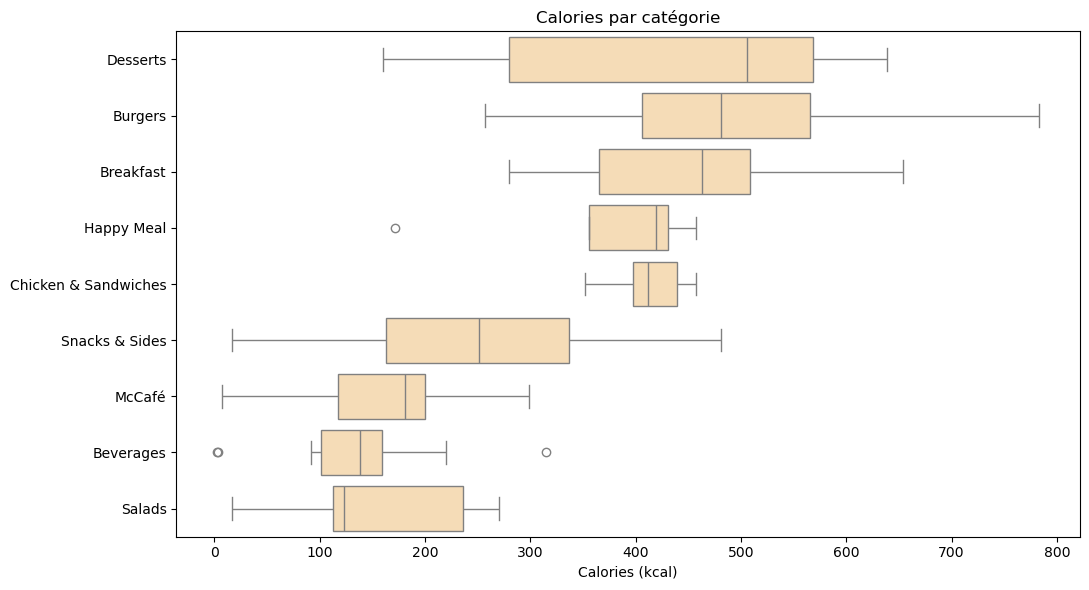

In [24]:
tab_cal = df_clean.groupby("category")["calories"].agg(["count", "mean", "median", "min", "max"]).round(0)
tab_cal = tab_cal.sort_values("median", ascending=False)
print(tab_cal)

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_clean, x="calories", y="category",
            order=list(tab_cal.index), color="navajowhite")
plt.title("Calories par catégorie")
plt.xlabel("Calories (kcal)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Observation :

Les médianes vont de 123 kcal (Salads) à 506 kcal (Desserts).
Le classement est : Desserts (506), Burgers (482), Breakfast (463), Happy Meal (420), Chicken & Sandwiches (412), Snacks & Sides (251), McCafé (182), Beverages (138), Salads (123).
Les extrêmes du menu sont dans Burgers (maximum de 783 kcal) et Beverages (minimum de 3 kcal).
Les catégories les plus étalées sont Desserts (de 160 à 639 kcal) et Burgers (de 257 à 783 kcal).

### Interprétation :

Les catégories se répartissent en deux niveaux : cinq catégories entre 412 et 506 kcal en médiane (Desserts, Burgers, Breakfast, Happy Meal, Chicken & Sandwiches), et quatre entre 123 et 251 kcal (Snacks & Sides, McCafé, Beverages, Salads).
Le classement calorique ne suit pas le classement des prix. Desserts est peu cher (≈ 2,98 $ en moyenne) mais le plus calorique en médiane, et Salads est cher (≈ 5,76 $) mais le moins calorique. Cela explique que la corrélation prix × calories reste modérée (r ≈ 0,41).
Pour Desserts (moyenne 428, médiane 506) et Happy Meal (367 contre 420), la moyenne est inférieure à la médiane : quelques produits peu caloriques tirent la moyenne vers le bas.

### Limitation :

Les calories sont données par portion, et les portions ne sont pas comparables entre un dessert, un burger et une boisson.
Salads (5 lignes) et Happy Meal (4 lignes) ont des résultats fragiles.
Les boîtes très larges (Desserts, Burgers) signalent des catégories hétérogènes : la médiane ne représente pas bien chaque produit.

### Barplot des moyennes/médianes
Quelles catégories ont les niveaux les plus élevés ou faibles ?

In [25]:
tab_cal = df_clean.groupby("category")["calories"].agg(["count", "mean", "median"]).round(0)
tab_cal = tab_cal.sort_values("median", ascending=False)

print("Niveaux les plus élevés :")
print(tab_cal.head(3))
print("\nNiveaux les plus faibles :")
print(tab_cal.tail(3))

Niveaux les plus élevés :
           count   mean  median
category                       
Desserts      11  428.0   506.0
Burgers       10  481.0   482.0
Breakfast     10  447.0   463.0

Niveaux les plus faibles :
           count   mean  median
category                       
McCafé        12  168.0   182.0
Beverages     12  134.0   138.0
Salads         5  152.0   123.0


Niveaux les plus élevés :
           count   mean  median
category                       
Desserts      11  428.0   506.0
Burgers       10  481.0   482.0
Breakfast     10  447.0   463.0

Niveaux les plus faibles :
           count   mean  median
category                       
McCafé        12  168.0   182.0
Beverages     12  134.0   138.0
Salads         5  152.0   123.0


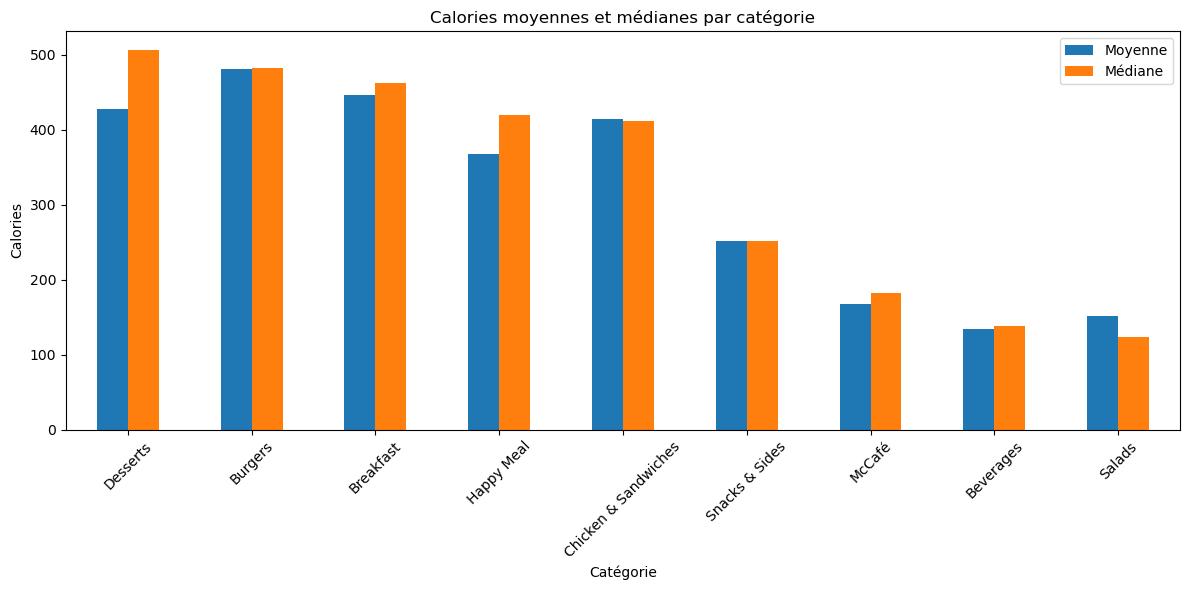

In [26]:
# Calculer la moyenne et la médiane des calories par catégorie
tab_cal = df_clean.groupby("category")["calories"].agg(
    ["count", "mean", "median"]
).round(0)

# Trier par médiane décroissante
tab_cal = tab_cal.sort_values("median", ascending=False)

# Afficher les catégories avec les niveaux les plus élevés et les plus faibles
print("Niveaux les plus élevés :")
print(tab_cal.head(3))

print("\nNiveaux les plus faibles :")
print(tab_cal.tail(3))

# Barplot des moyennes et médianes
tab_cal[["mean", "median"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Calories moyennes et médianes par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Calories")
plt.xticks(rotation=45)
plt.legend(["Moyenne", "Médiane"])
plt.tight_layout()
plt.show()

### Observation :
en médiane, les trois catégories les plus caloriques sont Desserts (506 kcal), Burgers (482 kcal) et Breakfast (463 kcal). Les trois moins caloriques sont Salads (123 kcal), Beverages (138 kcal) et McCafé (182 kcal). L'écart entre le haut et le bas du classement est de 383 kcal.

### Interprétation :

Les catégories de boissons et les salades sont les moins caloriques, ce qui est cohérent avec ce qu'elles contiennent.
Pour Salads, la moyenne (152 kcal) est supérieure à la médiane (123 kcal) : quelques salades plus caloriques tirent la moyenne vers le haut.
Pour Desserts, c'est l'inverse (moyenne 428, médiane 506) : quelques desserts légers tirent la moyenne vers le bas.
Le classement diffère donc de celui des prix, où Salads est dans le groupe cher.

### Limitation : 
Salads ne compte que 5 lignes, ce qui rend sa position fragile. Les calories sont données par portion, et les portions ne sont pas comparables entre catégories.

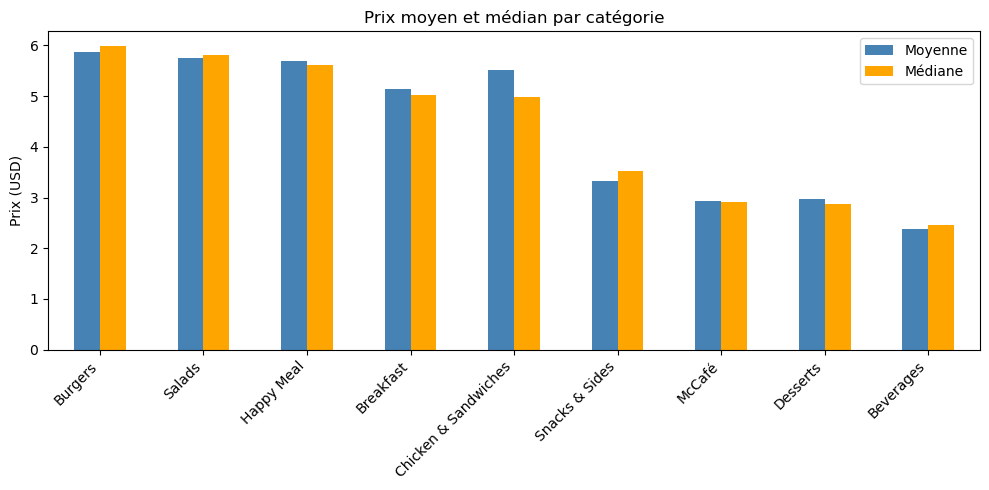

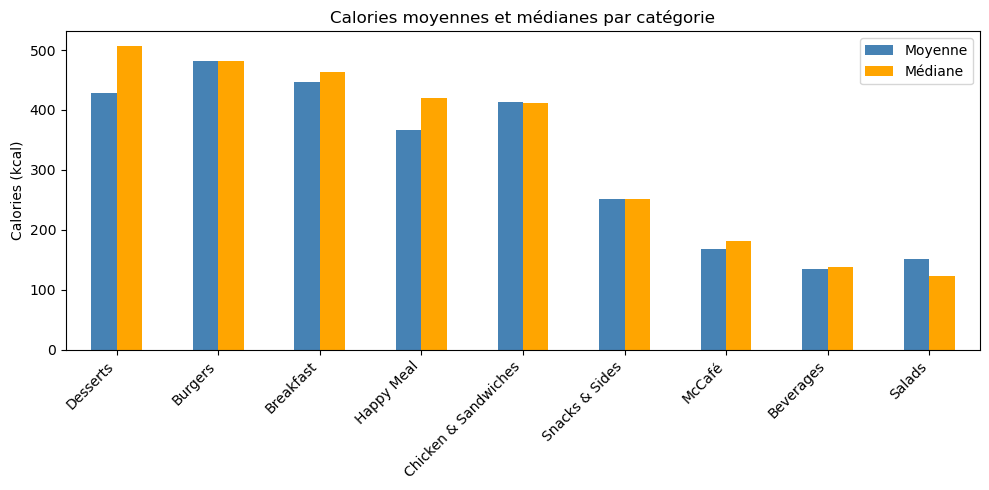

PRIX
Plus élevé  : Burgers -> 5.98 $
Plus faible : Beverages -> 2.45 $

CALORIES
Plus élevé  : Desserts -> 506.0 kcal
Plus faible : Salads -> 123.0 kcal

Catégories de moins de 6 lignes : ['Salads', 'Happy Meal']


In [27]:
# ÉTAPE 1 : calculer la moyenne et la médiane de chaque catégorie
prix = df_clean.groupby("category")["price_usd"].agg(["mean", "median"]).round(2)
calories = df_clean.groupby("category")["calories"].agg(["mean", "median"]).round(0)

# ÉTAPE 2 : trier du plus élevé au plus faible (selon la médiane)
prix = prix.sort_values("median", ascending=False)
calories = calories.sort_values("median", ascending=False)

# ÉTAPE 3 : graphique des prix
prix.plot(kind="bar", color=["steelblue", "orange"], figsize=(10, 5))
plt.title("Prix moyen et médian par catégorie")
plt.ylabel("Prix (USD)")
plt.xlabel("")
plt.legend(["Moyenne", "Médiane"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ÉTAPE 4 : graphique des calories
calories.plot(kind="bar", color=["steelblue", "orange"], figsize=(10, 5))
plt.title("Calories moyennes et médianes par catégorie")
plt.ylabel("Calories (kcal)")
plt.xlabel("")
plt.legend(["Moyenne", "Médiane"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ÉTAPE 5 : afficher les catégories les plus hautes et les plus basses
print("PRIX")
print("Plus élevé  :", prix["median"].idxmax(), "->", prix["median"].max(), "$")
print("Plus faible :", prix["median"].idxmin(), "->", prix["median"].min(), "$")

print("\nCALORIES")
print("Plus élevé  :", calories["median"].idxmax(), "->", calories["median"].max(), "kcal")
print("Plus faible :", calories["median"].idxmin(), "->", calories["median"].min(), "kcal")

# ÉTAPE 6 : repérer les catégories avec peu de produits (résultats fragiles)
effectif = df_clean["category"].value_counts()
print("\nCatégories de moins de 6 lignes :", list(effectif[effectif < 6].index))

### Observation :

Prix : la catégorie au prix médian le plus élevé est Burgers (5,98 $), la plus faible est Beverages (2,45 $). L'écart est de 3,53 $.
Calories : la médiane la plus élevée est celle de Desserts (506 kcal), la plus faible celle de Salads (123 kcal). L'écart est de 383 kcal.
Deux catégories ont moins de 6 lignes : Salads et Happy Meal.

### Interprétation :

Les extrêmes en prix et en calories ne sont pas les mêmes catégories. Burgers est en tête du prix mais seulement deuxième en calories, Desserts est en tête des calories mais parmi les moins chers, et Salads est dans le groupe cher mais tout en bas en calories.
Le niveau de prix d'une catégorie ne permet donc pas de prédire son niveau calorique, ce qui concorde avec une corrélation prix × calories modérée (r ≈ 0,41).
Comparer la moyenne et la médiane de chaque barre indique si la catégorie est homogène. Un écart important signale qu'un produit extrême tire la moyenne : c'est le cas de Desserts (moyenne 428, médiane 506) et de Salads (moyenne 152, médiane 123).

### Limitation :

Salads (5 lignes) et Happy Meal (4 lignes) ont des barres peu fiables. Il est notable que Salads soit l'extrême bas des calories : ce résultat repose sur seulement 5 produits.
Une barre résume une catégorie et cache sa dispersion (voir les boxplots, graphiques 3 et 4).
Le classement décrit le menu, il ne dit pas qu'une catégorie est « meilleure » qu'une autre.

### Scatter plot

Existe-t-il une relation entre deux variables numériques ?

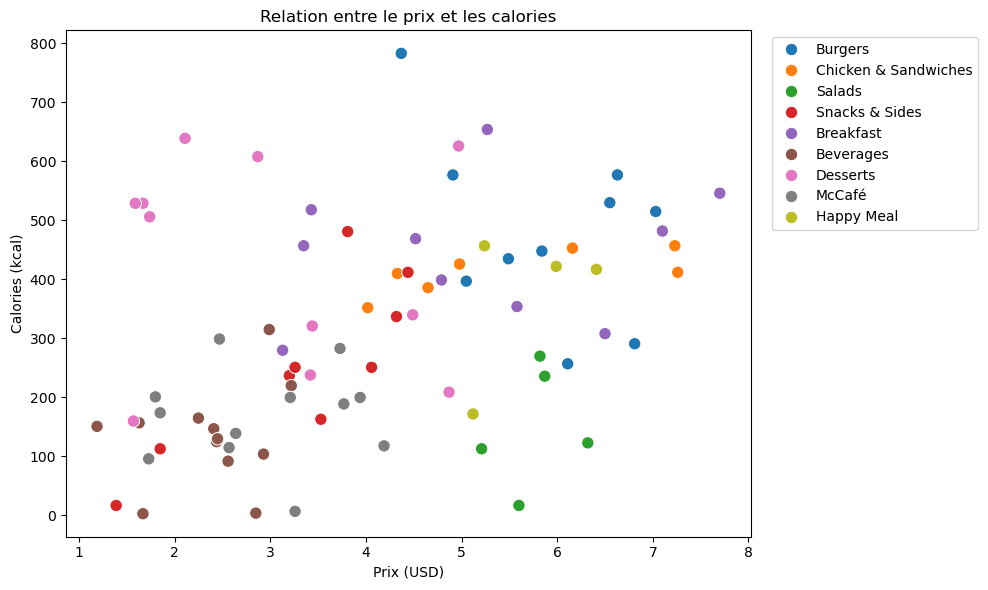

Corrélation prix x calories : 0.41
Relation modérée


In [28]:
# ÉTAPE 1 : le nuage de points (1 point = 1 produit)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="price_usd", y="calories", hue="category", s=80)
plt.title("Relation entre le prix et les calories")
plt.xlabel("Prix (USD)")
plt.ylabel("Calories (kcal)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ÉTAPE 2 : mesurer la relation avec un chiffre (coefficient de corrélation)
r = df_clean["price_usd"].corr(df_clean["calories"])
print("Corrélation prix x calories :", round(r, 2))

# ÉTAPE 3 : une phrase d'interprétation automatique
if abs(r) < 0.3:
    print("Relation faible")
elif abs(r) < 0.6:
    print("Relation modérée")
else:
    print("Relation forte")

### Observation :
le coefficient de corrélation de Pearson entre le prix et les calories est de r = 0,41, ce qui correspond à une relation modérée. Le nuage de points monte globalement de gauche à droite, mais il est très dispersé : des produits au prix proche ont des calories très différentes.

### Interprétation :

Les produits plus chers ont tendance à être plus caloriques, mais le prix ne permet pas de prédire précisément les calories.
En élevant r au carré (0,41² ≈ 0,17), on voit que seulement environ 17 % de la variation des calories est « partagée » avec celle du prix. Les 83 % restants s'expliquent par autre chose.
Vos résultats par catégorie montrent une cause probable : Desserts est peu cher mais le plus calorique en médiane (506 kcal), tandis que Salads est cher (≈ 5,76 $ en moyenne) mais le moins calorique (123 kcal). Ces catégories cassent la relation prix-calories.

### Limitation :

Corrélation ≠ causalité : le prix ne cause pas les calories, ni l'inverse.
Un seul coefficient global mélange toutes les catégories. Au sein d'une même catégorie, la relation peut être différente (plus forte ou plus faible).
Pearson mesure une relation en ligne droite et est sensible aux valeurs extrêmes. Pour vérifier, comparez avec Spearman.

### Heatmap 
Quelles variables numériques sont les plus corrélées ?

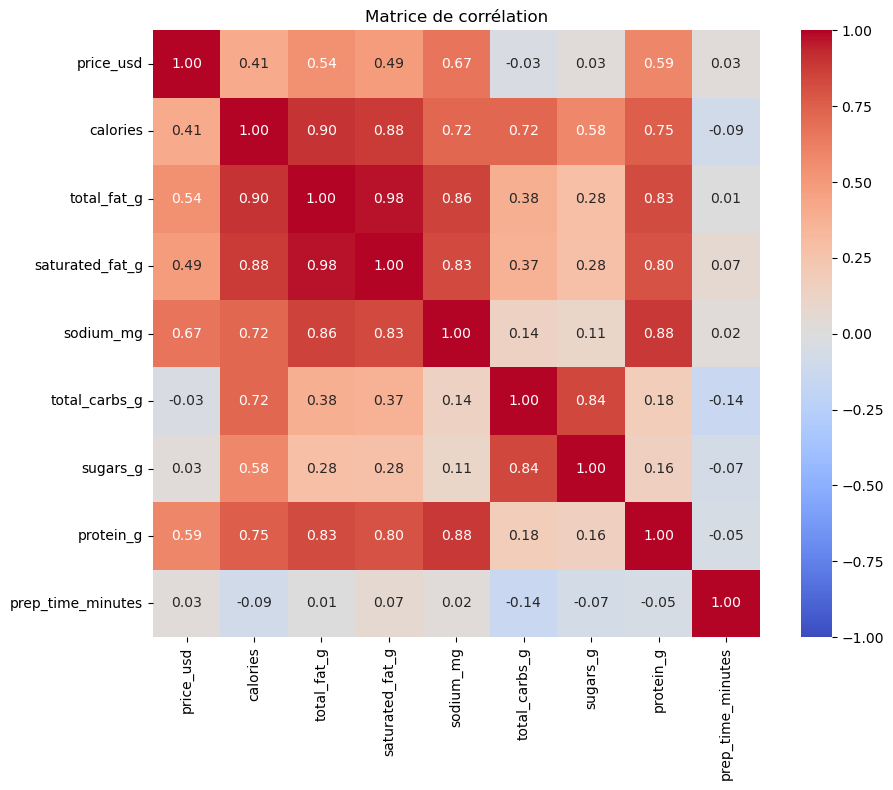

5 paires les plus corrélées :
saturated_fat_g  total_fat_g        0.98
calories         total_fat_g        0.90
protein_g        sodium_mg          0.88
calories         saturated_fat_g    0.88
sodium_mg        total_fat_g        0.86
dtype: float64

3 paires les moins corrélées (ou négatives) :
prep_time_minutes  sugars_g            -0.07
calories           prep_time_minutes   -0.09
prep_time_minutes  total_carbs_g       -0.14
dtype: float64


In [29]:
# ÉTAPE 1 : choisir les variables numériques utiles
# (on exclut les booléens et les colonnes déjà calculées : price_per_calorie, etc.)
variables = ["price_usd", "calories", "total_fat_g", "saturated_fat_g", "sodium_mg",
             "total_carbs_g", "sugars_g", "protein_g", "prep_time_minutes"]

# ÉTAPE 2 : calculer la matrice de corrélation
corr = df_clean[variables].corr()

# ÉTAPE 3 : dessiner la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# ÉTAPE 4 : lister les paires les plus corrélées
paires = corr.unstack()                            # transforme la matrice en liste de paires
paires = paires[paires.index.get_level_values(0) < paires.index.get_level_values(1)]   # supprime les doublons et la diagonale
paires = paires.sort_values(ascending=False)

print("5 paires les plus corrélées :")
print(paires.head(5).round(2))
print("\n3 paires les moins corrélées (ou négatives) :")
print(paires.tail(3).round(2))

### Observation :

Les paires les plus corrélées sont : lipides saturés × lipides totaux (0,98), calories × lipides totaux (0,90), protéines × sodium (0,88), calories × lipides saturés (0,88) et sodium × lipides totaux (0,86).
Les paires les moins corrélées sont toutes liées au temps de préparation : avec les sucres (−0,07), avec les calories (−0,09) et avec les glucides (−0,14).
Le prix est lié au sodium (≈ 0,67), aux protéines (≈ 0,59), aux lipides (≈ 0,54), et plus faiblement aux calories (≈ 0,41).

### Interprétation :

Le lien lipides saturés × lipides totaux (0,98) est quasi automatique : les lipides saturés sont une partie des lipides totaux. Le lien calories × lipides est lui aussi mécanique, car les calories se calculent à partir des macronutriments. Ces fortes valeurs apprennent peu.
Le lien protéines × sodium (0,88) est plus intéressant, car aucune formule ne relie ces deux variables. Il suggère que les produits à base de viande, de fromage ou d'œuf (burgers, sandwichs, petit-déjeuner) sont à la fois plus protéinés et plus salés.
C'est probablement ce même groupe de produits qui explique pourquoi le prix est plus lié au sodium et aux protéines qu'aux calories : la catégorie joue un rôle commun.
Le temps de préparation a des corrélations proches de zéro (entre −0,07 et −0,14) : il n'a pas de lien linéaire visible avec les calories, les sucres ou les glucides.

### Limitation :

Corrélation ≠ causalité : le sodium ne « fait » pas augmenter les protéines, et inversement. L'explication par les types de produits est une hypothèse que cette heatmap ne démontre pas.
Pearson mesure uniquement les relations en ligne droite et est sensible aux valeurs extrêmes. Comparez avec method="spearman" pour vérifier.
Des variables redondantes (lipides saturés et lipides totaux) gonflent la lecture de la matrice : mieux vaut n'en retenir qu'une dans une analyse approfondie.
Les coefficients faibles (−0,07 à −0,14) signalent l'absence de relation linéaire. Ils ne prouvent pas qu'aucune relation n'existe.

### Barplot horizontal Top N 

Quels produits sont extrêmes selon un KPI donné ?

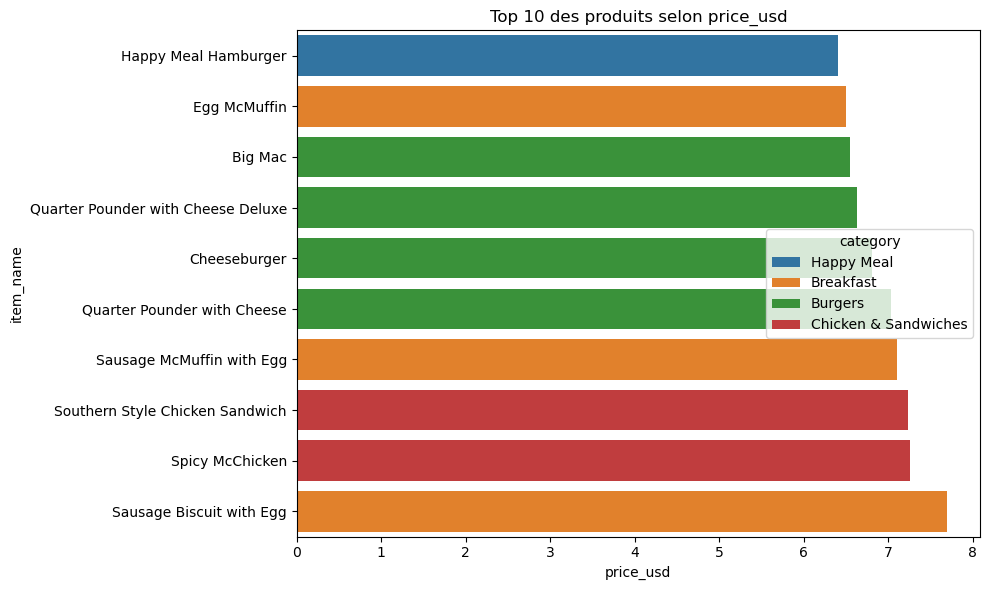

                         item_name             category  price_usd
          Sausage Biscuit with Egg            Breakfast       7.70
                   Spicy McChicken Chicken & Sandwiches       7.26
   Southern Style Chicken Sandwich Chicken & Sandwiches       7.23
         Sausage McMuffin with Egg            Breakfast       7.10
       Quarter Pounder with Cheese              Burgers       7.03
                      Cheeseburger              Burgers       6.81
Quarter Pounder with Cheese Deluxe              Burgers       6.63
                           Big Mac              Burgers       6.55
                      Egg McMuffin            Breakfast       6.50
              Happy Meal Hamburger           Happy Meal       6.41

Les 10 valeurs les plus faibles :
               item_name       category  price_usd
    Fanta Orange (Small)      Beverages       1.19
            Apple Slices Snacks & Sides       1.39
   Chocolate Chip Cookie       Desserts       1.57
Strawberry Shake (Small)

In [30]:
# ÉTAPE 1 : choisir l'indicateur (KPI) et le nombre de produits
kpi = "price_usd"        # à remplacer par "calories", "sodium_mg", "protein_g", "calories_par_dollar"...
n = 10

# ÉTAPE 2 : sélectionner les N produits les plus élevés
top = df_clean.nlargest(n, kpi)[["item_name", "category", kpi]]
top = top.sort_values(kpi)          # tri croissant pour que le plus grand soit en haut du graphique

# ÉTAPE 3 : graphique horizontal
plt.figure(figsize=(10, 6))
sns.barplot(data=top, x=kpi, y="item_name", hue="category", dodge=False)
plt.title(f"Top {n} des produits selon {kpi}")
plt.tight_layout()
plt.show()

# ÉTAPE 4 : afficher le tableau, du plus haut au plus bas
print(top.sort_values(kpi, ascending=False).to_string(index=False))

# ÉTAPE 5 : même chose pour les N produits les plus faibles
bas = df_clean.nsmallest(n, kpi)[["item_name", "category", kpi]]
print(f"\nLes {n} valeurs les plus faibles :")
print(bas.to_string(index=False))

### Observation :

Les 10 plus chers vont de 6,41 $ (Happy Meal Hamburger) à 7,70 $ (Sausage Biscuit with Egg). Ils se répartissent entre Burgers (4 produits), Breakfast (3), Chicken & Sandwiches (2) et Happy Meal (1).
Les 10 moins chers vont de 1,19 $ (Fanta Orange Small) à 1,80 $ (Mocha Small). Ils viennent de Desserts (4), Beverages (3), McCafé (2) et Snacks & Sides (1).
8 produits sur 10 du bas du classement sont en taille Small.
L'écart entre le produit le plus cher et le moins cher est de 6,51 $ (7,70 − 1,19).

### Interprétation :

Le haut du classement est entièrement composé de plats (sandwichs, burgers, petit-déjeuner), le bas de boissons, desserts et accompagnements. C'est cohérent avec les prix par catégorie : le type de produit structure le prix.
Le bas du classement dépend beaucoup de la taille : ce sont surtout les petites tailles qui sont les moins chères, pas forcément les produits les moins chers à taille égale.

### Limitation :

Plusieurs prix du haut du classement sont peu réalistes par rapport à ce que l'on attend d'un menu réel :
le Cheeseburger (6,81 $) est plus cher que le Big Mac (6,55 $) ;
le Spicy McChicken (7,26 $) dépasse le Quarter Pounder with Cheese Deluxe (6,63 $) ;
le Sausage Biscuit with Egg (7,70 $) est plus cher que tous les burgers.
Ces écarts sont des anomalies potentielles : le dataset est peut-être en partie simulé. Je ne peux pas le prouver avec ces seules données, mais il faut le signaler sans supprimer ces lignes.
Le prix maximum n'est pas un atypique statistique : la borne haute de la règle de l'IQR est d'environ 9,37 $ (5,32 + 1,5 × 2,70), donc 7,70 $ reste dans l'intervalle. « Extrême » ici veut dire « en tête du classement », pas « erreur ».


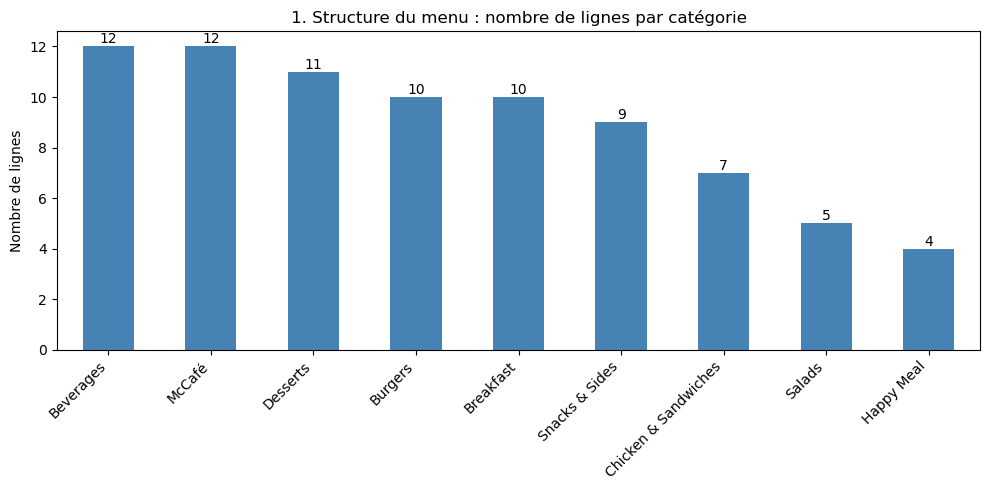

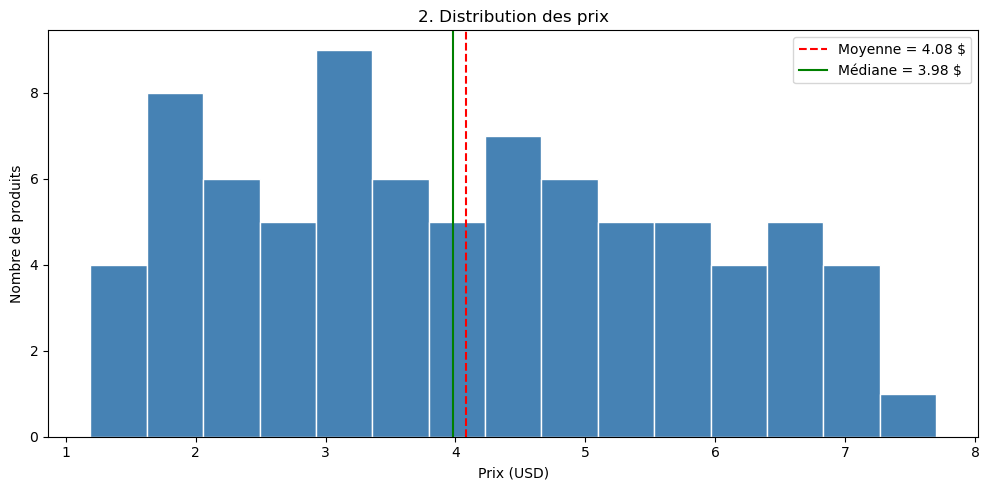

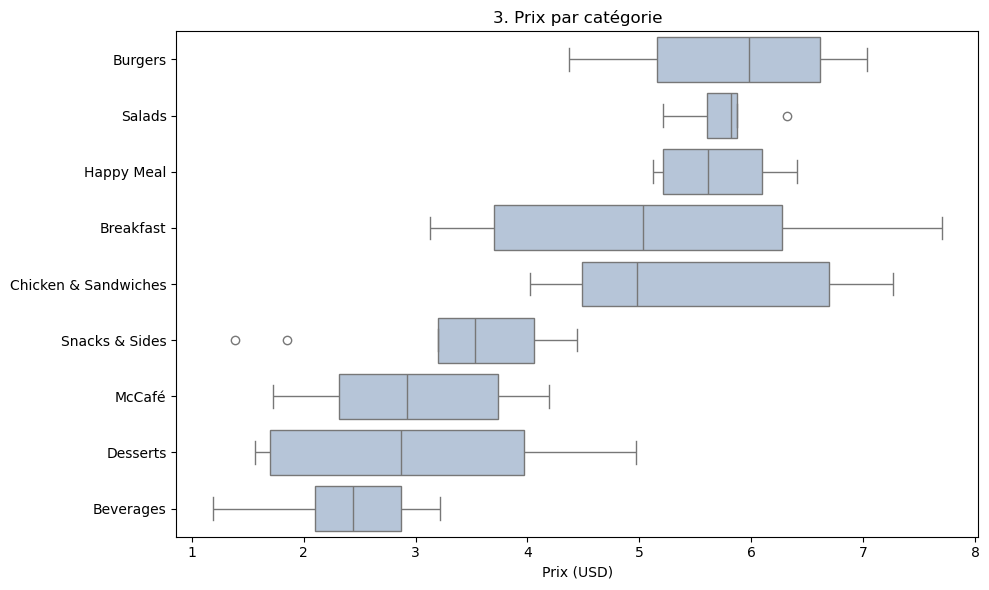

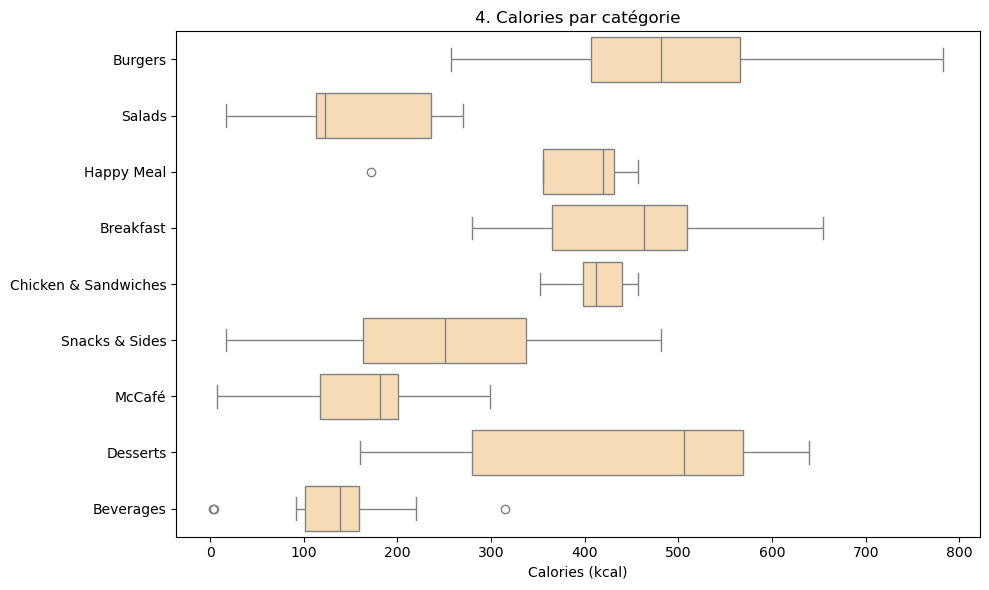

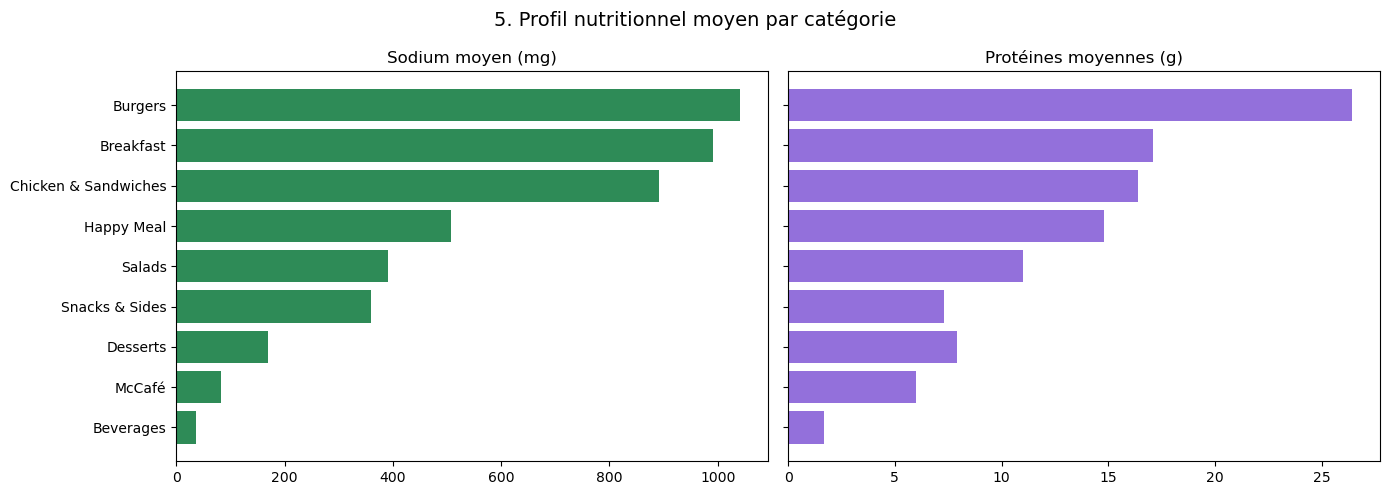

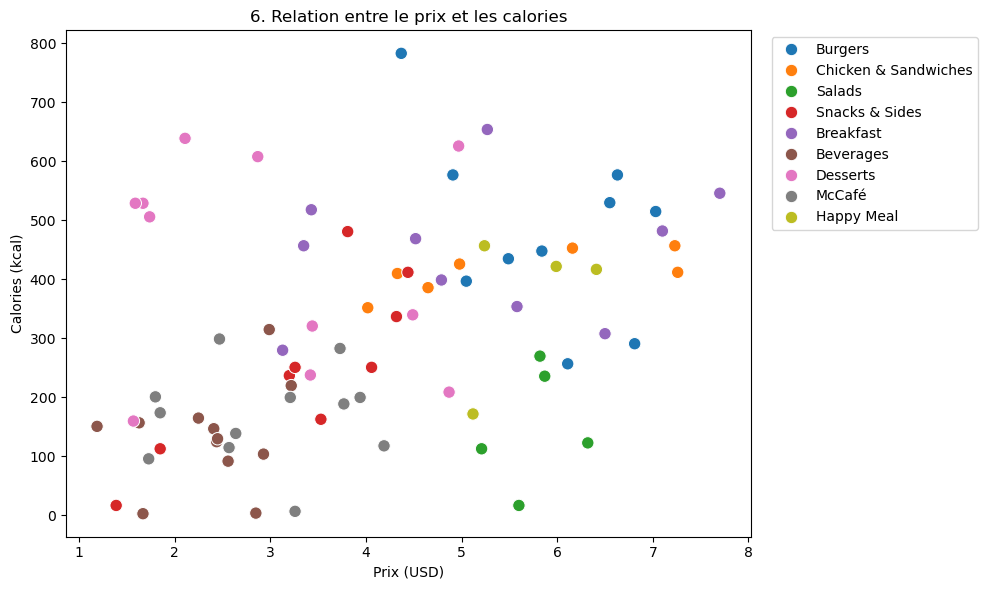

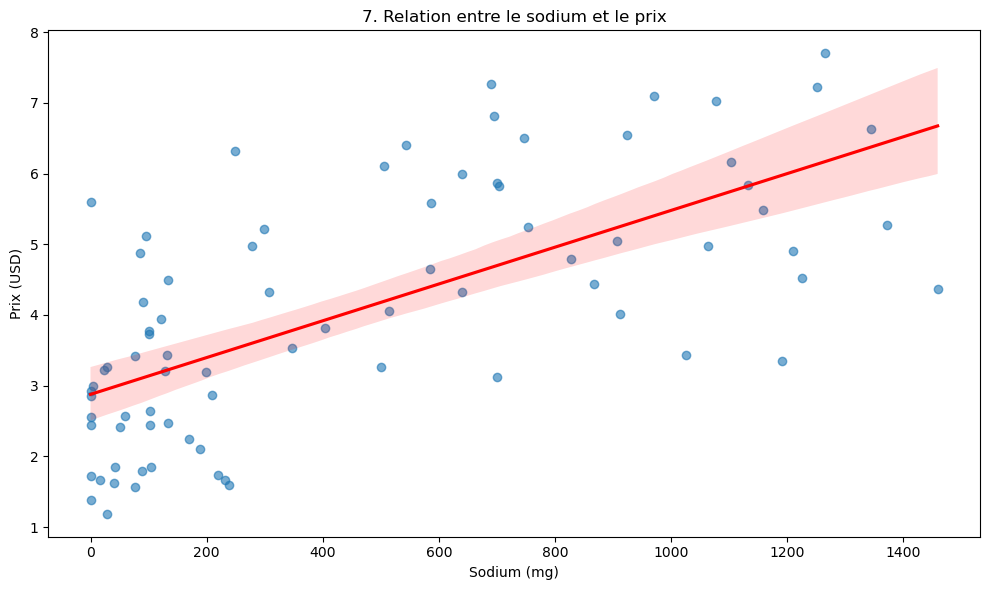

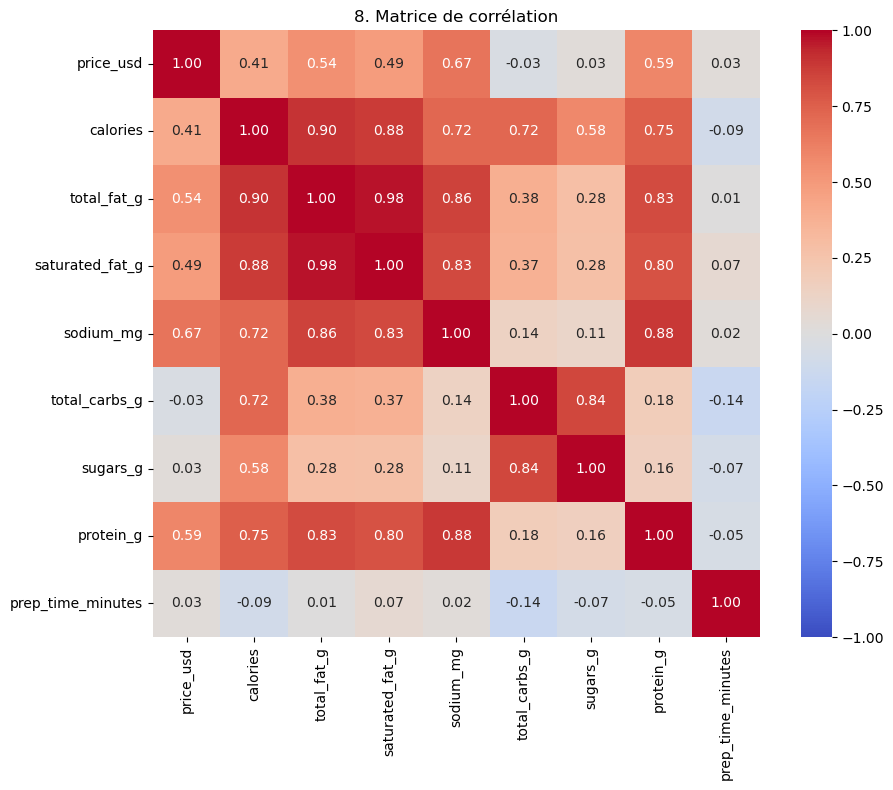

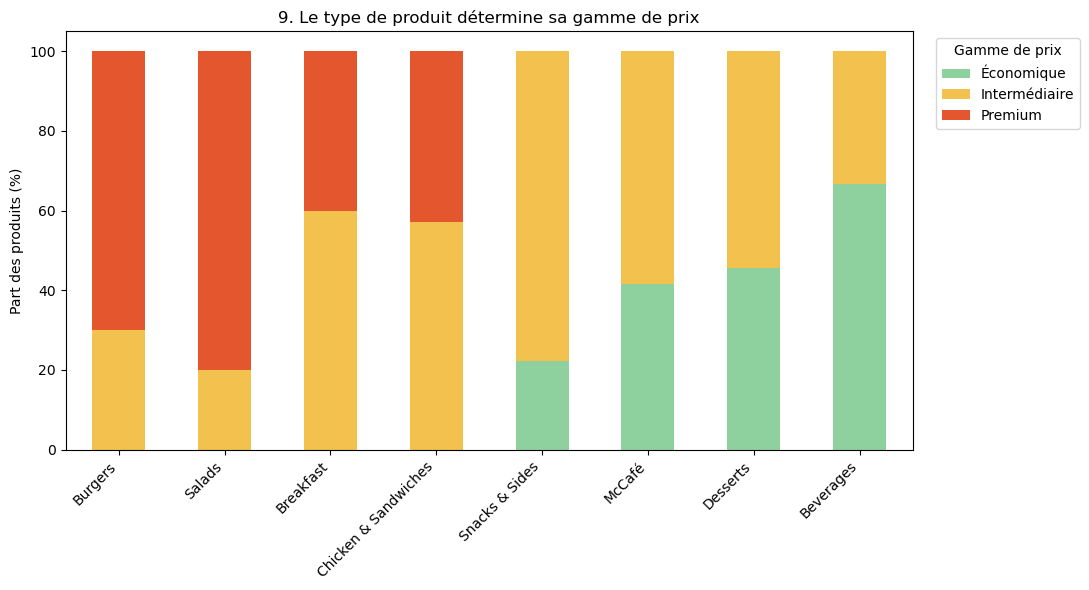

Prix moyen / médian : 4.08 / 3.98
Catégorie la plus chère (médiane) : Burgers
Catégorie la moins chère (médiane): Beverages
Corrélation prix x calories : 0.41
Corrélation prix x sodium   : 0.67
Corrélation calories x lipides : 0.9

Répartition des gammes de prix (%) :
gamme_prix            Économique  Intermédiaire  Premium
category                                                
Burgers                      0.0           30.0     70.0
Salads                       0.0           20.0     80.0
Breakfast                    0.0           60.0     40.0
Chicken & Sandwiches         0.0           57.1     42.9
Snacks & Sides              22.2           77.8      0.0
McCafé                      41.7           58.3      0.0
Desserts                    45.5           54.5      0.0
Beverages                   66.7           33.3      0.0


In [31]:
# ============================================================
# VISUALISATIONS FINALES (9 graphiques)
# Pré-requis : df_clean (avec les colonnes gamme_prix et taille) déjà créé dans le notebook
# ============================================================

# --- Préparation : si la colonne gamme_prix n'existe pas encore, on la crée (seuils = quartiles) ---
if "gamme_prix" not in df_clean.columns:
    q1 = df_clean["price_usd"].quantile(0.25)
    q3 = df_clean["price_usd"].quantile(0.75)
    df_clean["gamme_prix"] = pd.cut(df_clean["price_usd"], bins=[0, q1, q3, np.inf],
                                    labels=["Économique", "Intermédiaire", "Premium"], include_lowest=True)

# Ordre des catégories, de la plus chère à la moins chère (médiane des prix)
ordre = df_clean.groupby("category")["price_usd"].median().sort_values(ascending=False).index


# ------------------------------------------------------------
# 1. STRUCTURE DU MENU : combien de lignes par catégorie ?
# ------------------------------------------------------------
effectifs = df_clean["category"].value_counts()

ax = effectifs.plot(kind="bar", color="steelblue", figsize=(10, 5))
ax.bar_label(ax.containers[0])
plt.title("1. Structure du menu : nombre de lignes par catégorie")
plt.xlabel("")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. PRIX : comment les prix sont-ils distribués ?
# ------------------------------------------------------------
prix = df_clean["price_usd"]

plt.figure(figsize=(10, 5))
plt.hist(prix, bins=15, color="steelblue", edgecolor="white")
plt.axvline(prix.mean(), color="red", linestyle="--", label=f"Moyenne = {prix.mean():.2f} $")
plt.axvline(prix.median(), color="green", label=f"Médiane = {prix.median():.2f} $")
plt.title("2. Distribution des prix")
plt.xlabel("Prix (USD)")
plt.ylabel("Nombre de produits")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. PRIX : comment varient-ils entre catégories ?
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="price_usd", y="category", order=ordre, color="lightsteelblue")
plt.title("3. Prix par catégorie")
plt.xlabel("Prix (USD)")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. CALORIES : comment varient-elles entre catégories ?
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="calories", y="category", order=ordre, color="navajowhite")
plt.title("4. Calories par catégorie")
plt.xlabel("Calories (kcal)")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. NUTRITION : sodium et protéines moyens par catégorie
# ------------------------------------------------------------
nutri = df_clean.groupby("category")[["sodium_mg", "protein_g"]].mean().round(1)
nutri = nutri.sort_values("sodium_mg")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].barh(nutri.index, nutri["sodium_mg"], color="seagreen")
axes[0].set_title("Sodium moyen (mg)")
axes[1].barh(nutri.index, nutri["protein_g"], color="mediumpurple")
axes[1].set_title("Protéines moyennes (g)")
plt.suptitle("5. Profil nutritionnel moyen par catégorie", fontsize=14)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. RELATION : prix x calories (1 point = 1 produit)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="price_usd", y="calories", hue="category", s=80)
plt.title("6. Relation entre le prix et les calories")
plt.xlabel("Prix (USD)")
plt.ylabel("Calories (kcal)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. RELATION : prix x sodium (avec droite de tendance)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x="sodium_mg", y="price_usd",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("7. Relation entre le sodium et le prix")
plt.xlabel("Sodium (mg)")
plt.ylabel("Prix (USD)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. CORRÉLATIONS : heatmap
# ------------------------------------------------------------
variables = ["price_usd", "calories", "total_fat_g", "saturated_fat_g", "sodium_mg",
             "total_carbs_g", "sugars_g", "protein_g", "prep_time_minutes"]
corr = df_clean[variables].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("8. Matrice de corrélation")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. GRAPHIQUE FINAL (composition) : comment les gammes de prix
#    se répartissent-elles entre les catégories pertinentes ?
#    On garde les catégories d'au moins 5 lignes (sinon les % sont trop fragiles)
# ------------------------------------------------------------
cat_ok = effectifs[effectifs >= 5].index
data = df_clean[df_clean["category"].isin(cat_ok)]

compo = pd.crosstab(data["category"], data["gamme_prix"], normalize="index") * 100
compo = compo.loc[[c for c in ordre if c in compo.index]].round(1)

compo.plot(kind="bar", stacked=True, figsize=(11, 6), color=["#8fd19e", "#f2c14e", "#e4572e"])
plt.title("9. Le type de produit détermine sa gamme de prix")
plt.xlabel("")
plt.ylabel("Part des produits (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gamme de prix", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# CHIFFRES CLÉS (pour rédiger Observation / Interprétation)
# ------------------------------------------------------------
print("Prix moyen / médian :", round(prix.mean(), 2), "/", round(prix.median(), 2))
print("Catégorie la plus chère (médiane) :", ordre[0])
print("Catégorie la moins chère (médiane):", ordre[-1])
print("Corrélation prix x calories :", round(df_clean["price_usd"].corr(df_clean["calories"]), 2))
print("Corrélation prix x sodium   :", round(df_clean["price_usd"].corr(df_clean["sodium_mg"]), 2))
print("Corrélation calories x lipides :", round(df_clean["calories"].corr(df_clean["total_fat_g"]), 2))
print("\nRépartition des gammes de prix (%) :")
print(compo)

# Conclusion data visualisation
Dans ce dataset, la catégorie d'un produit structure nettement son prix, les plats se situant dans les gammes élevées et les boissons, desserts et accompagnements dans les gammes basses. En revanche, elle structure moins clairement les calories : Desserts est la catégorie la plus calorique en médiane, et Salads la moins calorique. Le prix est donc plus fortement associé au sodium (r ≈ 0,67) et aux protéines (r ≈ 0,59) qu'aux calories (r ≈ 0,41), et ces deux variables sont elles-mêmes très liées (r ≈ 0,88), probablement parce que les plats salés et protéinés sont aussi les plus chers. Ces relations sont descriptives : elles ne prouvent aucune causalité et reposent sur un dataset de 80 lignes dont certains prix paraissent peu réalistes.